# Taige Continuum Symmetric HF

Native Chiral_DW workflow for Taige-parameter tMoTe2: continuum bands, Chern numbers, density vertices/form factors, dual-gated smeared Coulomb HF, three constrained references, the symmetric convex trial Hamiltonian, and the post-HF chiral-domain-wall charge response.

The notebook is organized so that parameters appear only when the next stage needs them. You should be able to change HF iteration controls without rerunning the continuum band plot, and change the domain-wall texture after HF without rerunning HF.


## Setup Imports

This cell imports the numerical stack and Chiral_DW APIs used throughout the notebook. It also makes the local `src/` tree importable when the notebook is launched from either the repository root or the `notebooks/` directory.

In [60]:

from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython.display import clear_output, display
except ImportError:  # pragma: no cover - only used outside notebooks
    clear_output = None

    def display(obj):
        print(obj)

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from chiral_dw.config import (
    ContinuumFiniteQParams,
    ContinuumGridParams,
    ContinuumHFParams,
    DomainWallParams,
)
from chiral_dw.continuum import (
    SymmetricHFReferences,
    TPrimeConstraint,
    ValleyU1Constraint,
    active_basis_frames,
    build_continuum_bundle,
    build_seed,
    chern_number_table,
    compute_hf_diagnostics,
    compute_taige_path_spectrum,
    finite_q_shift_metadata,
    mix_projector_seeds,
    projector_maps,
    random_projector_like_seed,
    reference_diagnostics,
    solve_hf,
    symmetric_convex_path,
    taige_interaction_params,
    taige_ivc_minus_half_shift_coord,
    taige_ivc_minus_q_coord,
    taige_model_params,
)
from chiral_dw.domain_wall import charge_density_radial
from chiral_dw.response import k_theta_from_projectors_with_basis

plt.rcParams.update({"figure.dpi": 120})

## Continuum Model Parameters

These are the only parameters needed to inspect the non-interacting continuum bands. The defaults are Taige's MoTe2 values with the requested starting point `theta_deg = 3.5` and `u_D = 0`.

`plane_wave_shell` controls the plane-wave cutoff in the continuum diagonalization. The band plot is sensitive to this cutoff: small values can visibly break the expected K/Kprime time-reversal overlap along the path.


In [77]:

# Continuum model parameters.
theta_deg = 3.5
u_D = 10.0
plane_wave_shell = 5
n_bands = 2

# Band-plot resolution along each high-symmetry path segment.
path_n_per_segment = 48

run_label = f"theta{theta_deg:g}_uD{u_D:g}_shell{plane_wave_shell}"
result_dir = ROOT / "results" / "taige_continuum_symmetric_hf" / run_label
result_dir.mkdir(parents=True, exist_ok=True)

model = taige_model_params(
    theta_deg=theta_deg,
    u_D=u_D,
    plane_wave_shell=plane_wave_shell,
    n_bands=n_bands,
)

print(model)
print("result_dir:", result_dir)

theta_deg=3.5 a0_angstrom=3.47 m_eff=0.62 moire_potential_mev=11.2 phi_deg=91.0 tunneling_mev=-13.3 displacement_mev=10.0 plane_wave_shell=5 n_bands=2 n_active_bands_per_valley=1 active_model='taige'
result_dir: /Users/nisargchadha/Documents/Chiral_DW/results/taige_continuum_symmetric_hf/theta3.5_uD10_shell5


## Continuum Band Structure

This cell diagonalizes the non-interacting continuum Hamiltonian along the standard Taige path. The Kprime branch is generated in the same T-prime convention used for the active-space mesh: it is evaluated from the K valley at folded `-k`, rather than by comparing to a separately gauged direct Kprime Hamiltonian.

The diagnostic printout checks the maximum K/Kprime mismatch in the plotted hole bands and whether the lowest plotted hole band has its maximum at Gamma.


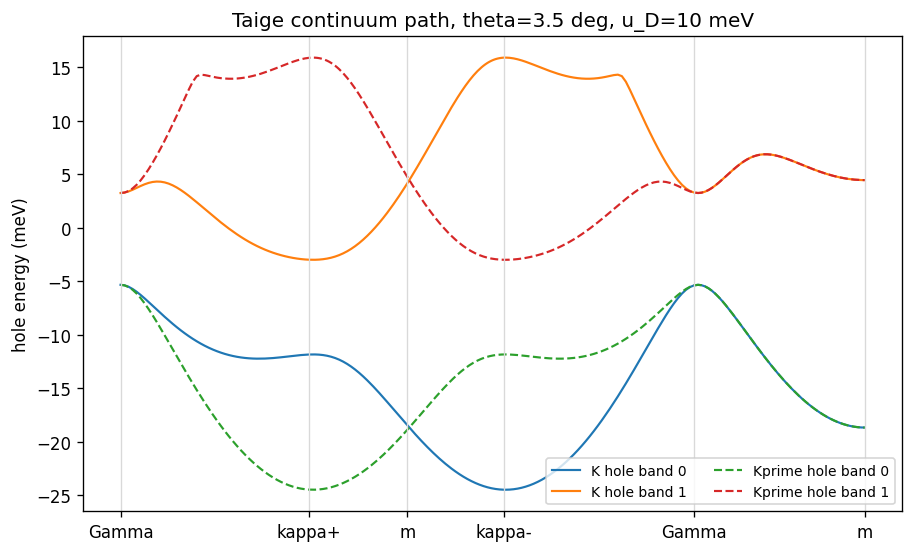

In [78]:

path_data = compute_taige_path_spectrum(model, n_per_segment=path_n_per_segment)
distances = path_data["distances"]
ticks = path_data["ticks"]
labels = path_data["labels"]
hole_path = path_data["hole_energies"]
gamma_index = ticks[0]
valley_mismatch = float(np.max(np.abs(hole_path[:, 0, :] - hole_path[:, 1, :])))
lowest_hole_peak_index = int(np.argmax(hole_path[:, 0, 0]))

fig, ax = plt.subplots(figsize=(7.5, 4.5), constrained_layout=True)
for iv, valley in enumerate(("K", "Kprime")):
    style = "-" if valley == "K" else "--"
    for band in range(hole_path.shape[-1]):
        ax.plot(distances, hole_path[:, iv, band], style, lw=1.3, label=f"{valley} hole band {band}")
for tick in ticks:
    ax.axvline(distances[tick], color="0.85", lw=0.8)
ax.set_xticks([distances[t] for t in ticks], labels)
ax.set_ylabel("hole energy (meV)")
ax.set_title(f"Taige continuum path, theta={theta_deg:g} deg, u_D={u_D:g} meV")
ax.legend(fontsize="small", ncols=2)
fig.savefig(result_dir / "continuum_band_path.png", dpi=180)
plt.show()

## Active Space And Interaction Parameters

The continuum band plot above does not require an HF mesh or Coulomb kernel. Those controls enter here, where we build the active hole basis, density vertices/form factors, and dual-gated smeared Coulomb weights used by HF.

Increase `n_k`, `q_mesh`, `q_shell`, and `local_field_cutoff` for more faithful production runs. The default is intentionally modest so the notebook remains interactive.


In [79]:

n_active_bands_per_valley = 1
n_k = 18

q_mesh = "full"  # "shell" for quick scans, "full" for all mesh transfers
q_shell = 0
local_field_cutoff = 4
include_q0 = True

model = model.model_copy(
    update={"n_active_bands_per_valley": n_active_bands_per_valley}
)
interaction = taige_interaction_params(
    include_q0=include_q0,
    q_mesh=q_mesh,
    q_shell=q_shell,
    local_field_cutoff=local_field_cutoff,
)
grid_params = ContinuumGridParams(n_k=n_k)

bundle = build_continuum_bundle(model=model, grid=grid_params, interaction=interaction)
active = bundle.active
vertices = bundle.vertices
backend = bundle.backend

print(model)
print(interaction)
print("grid blocks:", active.n_k)
print("active block dimension:", active.dim)
print("plane waves per layer:", active.n_plane_waves)
print("h0:", active.h0.shape)
print("hole vectors:", active.band_vectors.shape)
print("lambda blocks:", vertices.lambda_blocks.shape)
print("v_over_a:", vertices.v_over_a.shape)
print("nonzero interaction channels:", int(np.count_nonzero(vertices.v_over_a)))
print("T-prime sewing quality min:", float(np.min(bundle.bands.tprime_sewing_quality)))

theta_deg=3.5 a0_angstrom=3.47 m_eff=0.62 moire_potential_mev=11.2 phi_deg=91.0 tunneling_mev=-13.3 displacement_mev=10.0 plane_wave_shell=5 n_bands=2 n_active_bands_per_valley=1 active_model='taige'
v0=1.0 gate_distance=2.0 q0_hartree='omit_uniform' q_shell=0 q_mesh='full' local_field_cutoff=4 coulomb_kind='dual_gate' epsilon=16.7 gate_distance_nm=30.0 include_q0=True smear_length_nm=0.34700000000000003 exchange_scale=1.0 hartree_scale=1.0 reference_density='zero'
grid blocks: 324
active block dimension: 2
plane waves per layer: 91
h0: (324, 2, 2)
hole vectors: (324, 2, 182, 1)
lambda blocks: (324, 81, 324, 2, 2)
v_over_a: (324, 81)
nonzero interaction channels: 14071
T-prime sewing quality min: 0.9999999970036222


## Chern Numbers

This cell computes Fukui Chern numbers for the selected active hole band and its electron counterpart on the same coarse mesh used for HF. The signs provide a quick convention check for the opposite-Chern K and Kprime active bands.


In [80]:

chern_rows = chern_number_table(bundle.bands, band_indices=tuple(range(n_active_bands_per_valley)))
for row in chern_rows:
    print(f"{row.basis:8s} {row.valley:6s} band {row.band}: C = {row.chern:+.6f}")

electron K      band 0: C = -1.000000
electron Kprime band 0: C = +1.000000
hole     K      band 0: C = +1.000000
hole     Kprime band 0: C = -1.000000


## Density Vertex And Coulomb Diagnostics

This cell inspects the projected density vertex table and the interaction weights. The `q=0` density vertex should be the identity in the active subspace; a large error here would indicate a form-factor convention problem before HF begins.


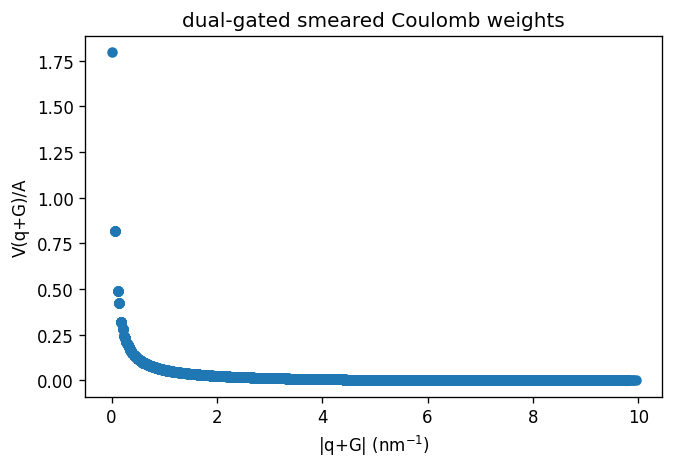

q=0 identity error: 1.9984014443252818e-15


In [81]:

q_norm = vertices.q_norm_nm_inv.reshape(-1) if vertices.q_norm_nm_inv is not None else np.arange(vertices.v_over_a.size)
weights = vertices.v_over_a.reshape(-1)

fig, ax = plt.subplots(figsize=(5.5, 3.8), constrained_layout=True)
ax.scatter(q_norm, weights, s=28)
ax.set_xlabel(r"|q+G| (nm$^{-1}$)")
ax.set_ylabel(r"V(q+G)/A")
ax.set_title("dual-gated smeared Coulomb weights")
fig.savefig(result_dir / "interaction_weights.png", dpi=180)
plt.show()

iq0 = vertices.q_shifts.index((0, 0))
q0_identity_error = np.max(np.abs(vertices.lambda_blocks[iq0, 0] - np.eye(active.dim)))
print("q=0 identity error:", float(q0_identity_error))

## Projector Visualization And HF Helpers

These helper functions are used by the HF cells below. They do not run HF or change the model; they only define common plots, seed construction, live iteration tables, and diagnostic summaries so the three reference solves have the same presentation.

The projector diagnostic combines a literal valley-space matrix view (`P_KK`, `|P_KKprime|`, `|P_KprimeK|`, `P_KprimeKprime`) with the two order-parameter maps that are most useful while HF is running. Fixed color limits make iteration-to-iteration comparisons meaningful.


In [82]:

def _figure_path(prefix, suffix):
    return result_dir / f"{prefix}_{suffix}.png"


def _display_and_close(fig):
    display(fig)
    plt.close(fig)


def plot_projector_diagnostics(P, title, active_for_plot=None):
    active_local = active if active_for_plot is None else active_for_plot
    maps = projector_maps(P, active_local)
    fig, axes = plt.subplots(3, 2, figsize=(9.2, 10.2), constrained_layout=True)
    specs = [
        (axes[0, 0], "P_KK", maps["P_KK"], "viridis", 0.0, 1.0),
        (axes[0, 1], "|P_KKprime|", maps["P_KKprime_abs"], "viridis", 0.0, 1.0),
        (axes[1, 0], "|P_KprimeK|", maps["P_KprimeK_abs"], "viridis", 0.0, 1.0),
        (axes[1, 1], "P_KprimeKprime", maps["P_KprimeKprime"], "viridis", 0.0, 1.0),
        (axes[2, 0], "valley polarization", maps["VP"], "coolwarm", -1.0, 1.0),
        (axes[2, 1], "|IVC|", maps["IVC_abs"], "viridis", 0.0, 0.5 * active_local.n_active),
    ]
    for ax, label, values, cmap, vmin, vmax in specs:
        image = ax.imshow(values, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(label)
        ax.set_xlabel("k2")
        ax.set_ylabel("k1")
        fig.colorbar(image, ax=ax, shrink=0.78)
    fig.suptitle(title)
    return fig


def noisy_initial_projector(seed_name, rng_seed, constraint, active_for_seed=None, hf_for_seed=None):
    active_local = active if active_for_seed is None else active_for_seed
    hf_local = hf_params if hf_for_seed is None else hf_for_seed
    ordered = build_seed(
        seed_name,
        active_local,
        n_occ_per_k=hf_local.n_occ_per_k,
        ivc_angle=hf_local.ivc_angle,
        ivc_phase=hf_local.ivc_phase,
        random_seed_value=rng_seed,
    )
    if constraint is not None:
        ordered = constraint.project_density(ordered)
    noise = random_projector_like_seed(ordered, seed=rng_seed)
    if constraint is not None:
        noise = constraint.project_density(noise)
    mixed = mix_projector_seeds(
        ordered,
        noise,
        ordered_weight=hf_local.seed_ordered_weight,
        random_weight=hf_local.seed_random_weight,
    )
    if constraint is not None:
        mixed = constraint.project_density(mixed)
    return mixed, ordered, noise


def projector_order_parameters(P, active_for_plot=None):
    active_local = active if active_for_plot is None else active_for_plot
    maps = projector_maps(P, active_local)
    return {
        "mean_VP": float(np.mean(maps["VP"])),
        "mean_abs_IVC": float(np.mean(maps["IVC_abs"])),
        "max_abs_IVC": float(np.max(maps["IVC_abs"])),
    }


def seed_diagnostics_row(label, P, constraint, active_for_plot=None):
    active_local = active if active_for_plot is None else active_for_plot
    maps = projector_maps(P, active_local)
    return {
        "seed": label,
        "trace": float(np.real(np.trace(P, axis1=-2, axis2=-1).sum())),
        "constraint_error": 0.0 if constraint is None else float(constraint.symmetry_error(P)),
        "mean_K": float(np.mean(maps["K"])),
        "mean_Kprime": float(np.mean(maps["Kprime"])),
        "mean_VP": float(np.mean(maps["VP"])),
        "mean_abs_IVC": float(np.mean(maps["IVC_abs"])),
        "max_abs_IVC": float(np.max(maps["IVC_abs"])),
    }


def hf_history_row(iteration, P, energy, diagnostics, active_for_plot=None):
    order = projector_order_parameters(P, active_for_plot)
    return {
        "iteration": int(iteration),
        "energy": float(energy),
        "delta_energy": float(diagnostics.delta_energy),
        "delta_P": float(diagnostics.delta_P),
        "idempotency_fro": float(diagnostics.idempotency_error_fro),
        "idempotency_max": float(diagnostics.idempotency_error_max),
        "aufbau_residual": float(diagnostics.aufbau_residual_norm),
        "commutator": float(diagnostics.commutator_norm),
        "trace_error": float(diagnostics.trace_error),
        "constraint_error": float(diagnostics.constraint_error),
        "direct_gap": float(diagnostics.direct_gap_min),
        "indirect_gap": float(diagnostics.indirect_gap),
        "lambda": np.nan if diagnostics.lambda_value is None else float(diagnostics.lambda_value),
        "fallback": "" if diagnostics.fallback_reason is None else diagnostics.fallback_reason,
        "density_kind": diagnostics.density_kind,
        **order,
    }


def _positive(values):
    arr = np.nan_to_num(np.abs(np.asarray(values, dtype=float)), nan=0.0)
    return np.maximum(arr, 1e-16)


def plot_hf_history(history_df, title):
    fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
    x = history_df["iteration"]

    axes[0, 0].plot(x, history_df["energy"], marker="o", ms=2.5)
    axes[0, 0].set_title("energy")
    axes[0, 0].set_xlabel("iteration")

    axes[0, 1].plot(x, history_df["mean_VP"], marker="o", ms=2.5, label="mean VP")
    axes[0, 1].plot(x, history_df["mean_abs_IVC"], marker="o", ms=2.5, label="mean |IVC|")
    axes[0, 1].plot(x, history_df["max_abs_IVC"], marker="o", ms=2.5, label="max |IVC|")
    axes[0, 1].set_title("order parameters")
    axes[0, 1].set_xlabel("iteration")
    axes[0, 1].legend(fontsize="small")

    axes[0, 2].plot(x, history_df["direct_gap"], marker="o", ms=2.5, label="direct")
    axes[0, 2].plot(x, history_df["indirect_gap"], marker="o", ms=2.5, label="indirect")
    axes[0, 2].set_title("gaps")
    axes[0, 2].set_xlabel("iteration")
    axes[0, 2].legend(fontsize="small")

    for col in ("aufbau_residual", "commutator", "idempotency_fro"):
        axes[1, 0].semilogy(x, _positive(history_df[col]), marker="o", ms=2.5, label=col)
    axes[1, 0].set_title("self-consistency")
    axes[1, 0].set_xlabel("iteration")
    axes[1, 0].legend(fontsize="small")

    axes[1, 1].semilogy(x, _positive(history_df["delta_P"]), marker="o", ms=2.5, label="delta P")
    axes[1, 1].semilogy(
        x,
        _positive(history_df["delta_energy"]),
        marker="o",
        ms=2.5,
        label="delta energy",
    )
    axes[1, 1].set_title("updates")
    axes[1, 1].set_xlabel("iteration")
    axes[1, 1].legend(fontsize="small")

    axes[1, 2].semilogy(x, _positive(history_df["trace_error"]), marker="o", ms=2.5, label="trace")
    axes[1, 2].semilogy(
        x,
        _positive(history_df["constraint_error"]),
        marker="o",
        ms=2.5,
        label="constraint",
    )
    axes[1, 2].set_title("constraints")
    axes[1, 2].set_xlabel("iteration")
    axes[1, 2].legend(fontsize="small")

    fig.suptitle(title)
    return fig


def summarize_result(name, result):
    d = result.diagnostics
    print(f"{name}: energy={result.energy:.12g}, converged={result.converged}, iterations={result.n_iter}")
    print("  idempotency fro/max:", d.idempotency_error_fro, d.idempotency_error_max)
    print("  residual/commutator:", d.aufbau_residual_norm, d.commutator_norm)
    print("  trace/constraint:", d.trace_error, d.constraint_error)
    print("  direct/indirect gap:", d.direct_gap_min, d.indirect_gap)
    print("  snapshots:", [snapshot.iteration for snapshot in result.snapshots])


def run_live_hf(
    label,
    P0,
    constraint,
    seed,
    filename_prefix,
    backend_for_run=None,
    active_for_run=None,
    hf_for_run=None,
):
    backend_local = backend if backend_for_run is None else backend_for_run
    active_local = active if active_for_run is None else active_for_run
    hf_local = hf_params if hf_for_run is None else hf_for_run
    P_start = backend_local.as_block_density(P0)
    if constraint is not None:
        P_start = constraint.project_density(P_start)
    initial_diagnostics = compute_hf_diagnostics(
        backend_local,
        P_start,
        hf_local,
        constraint=constraint,
        iteration=0,
    )
    history = [hf_history_row(0, P_start, initial_diagnostics.energy, initial_diagnostics, active_local)]

    def record_iteration(iteration, P_iter, energy_iter, diagnostics_iter, is_snapshot):
        history.append(hf_history_row(iteration, P_iter, energy_iter, diagnostics_iter, active_local))
        if is_snapshot:
            if clear_output is not None:
                clear_output(wait=True)
            history_df = pd.DataFrame(history)
            display(history_df.tail(12))

            fig = plot_projector_diagnostics(
                P_iter,
                f"{label} projector after iteration {iteration}",
                active_local,
            )
            fig.savefig(_figure_path(filename_prefix, f"projector_iter_{iteration:04d}"), dpi=180)
            _display_and_close(fig)

    result = solve_hf(
        backend_local,
        P_start,
        hf_local,
        constraint=constraint,
        seed=seed,
        on_iteration=record_iteration,
    )
    history.append(
        hf_history_row(result.diagnostics.iteration, result.P, result.energy, result.diagnostics, active_local)
    )
    history_df = pd.DataFrame(history)
    history_df.to_csv(result_dir / f"{filename_prefix}_hf_history.csv", index=False)

    display(history_df.tail(15))
    summarize_result(label, result)

    fig = plot_hf_history(history_df, f"{label} constrained HF")
    fig.savefig(_figure_path(filename_prefix, "hf_history"), dpi=180)
    _display_and_close(fig)

    fig = plot_projector_diagnostics(result.P, f"{label} final projector", active_local)
    fig.savefig(_figure_path(filename_prefix, "final_projector"), dpi=180)
    _display_and_close(fig)
    return result, history_df



## Hartree-Fock Run Parameters

These controls are only needed once the active space and interaction backend exist. You can change iteration counts, tolerances, seed noise, and snapshot cadence here without rebuilding the continuum band plot above.

The seed weights implement the requested 0.8 ordered / 0.2 random projector-like mixture for VP+, VP-, and IVC initial conditions. The live display cadence controls how often the notebook refreshes the history table and projector plots during each HF solve.


In [83]:

hf_update_every = 10
hf_params = ContinuumHFParams(
    n_occ_per_k=1,
    max_iter=100,
    min_iter=3,
    mixing_method="oda",
    mixing=0.45,
    tolerance=1e-8,
    energy_tolerance=1e-10,
    seed_ordered_weight=0.8,
    seed_random_weight=0.2,
    random_seed=7,
    store_projector_snapshots=True,
    snapshot_interval=hf_update_every,
    first_iteration_snapshot=True,
)

print(hf_params)
print("hf_update_every:", hf_update_every)

n_occ_per_k=1 max_iter=100 min_iter=3 mixing_method='oda' mixing=0.45 oda_lambda_min=0.0001 tolerance=1e-08 energy_tolerance=1e-10 idempotency_tolerance=1e-08 final_residual_tolerance=1e-07 ivc_angle=1.5707963267948966 ivc_phase=0.0 random_seed=7 seed_ordered_weight=0.8 seed_random_weight=0.2 store_projector_snapshots=True snapshot_interval=10 first_iteration_snapshot=True
hf_update_every: 10


## Initial Noisy Projectors

This cell constructs and displays the actual initial projectors for the three HF references. Each ordered VP/IVC seed is mixed with a projector-like random Slater seed using the weights in `hf_params`, then projected into the same symmetry channel used by the corresponding HF solve.

The figures and table are meant to catch obvious seed mistakes before the self-consistency loop starts: VP seeds should have zero intervalley blocks but may have diagonal occupation in both valleys, while the IVC seed should show intervalley coherence in the off-diagonal panels and finite `|IVC|`.


,seed,trace,constraint_error,mean_K,mean_Kprime,mean_VP,mean_abs_IVC,max_abs_IVC
0,VP+ initial,324.0,0.0,0.901372,0.098628,8.027440e-01,0.000000,0.000000
1,VP- initial,324.0,0.0,0.098946,0.901054,-8.021090e-01,0.000000,0.000000
2,IVC initial,324.0,0.0,0.500000,0.500000,-1.713307e-19,0.399707,0.486316


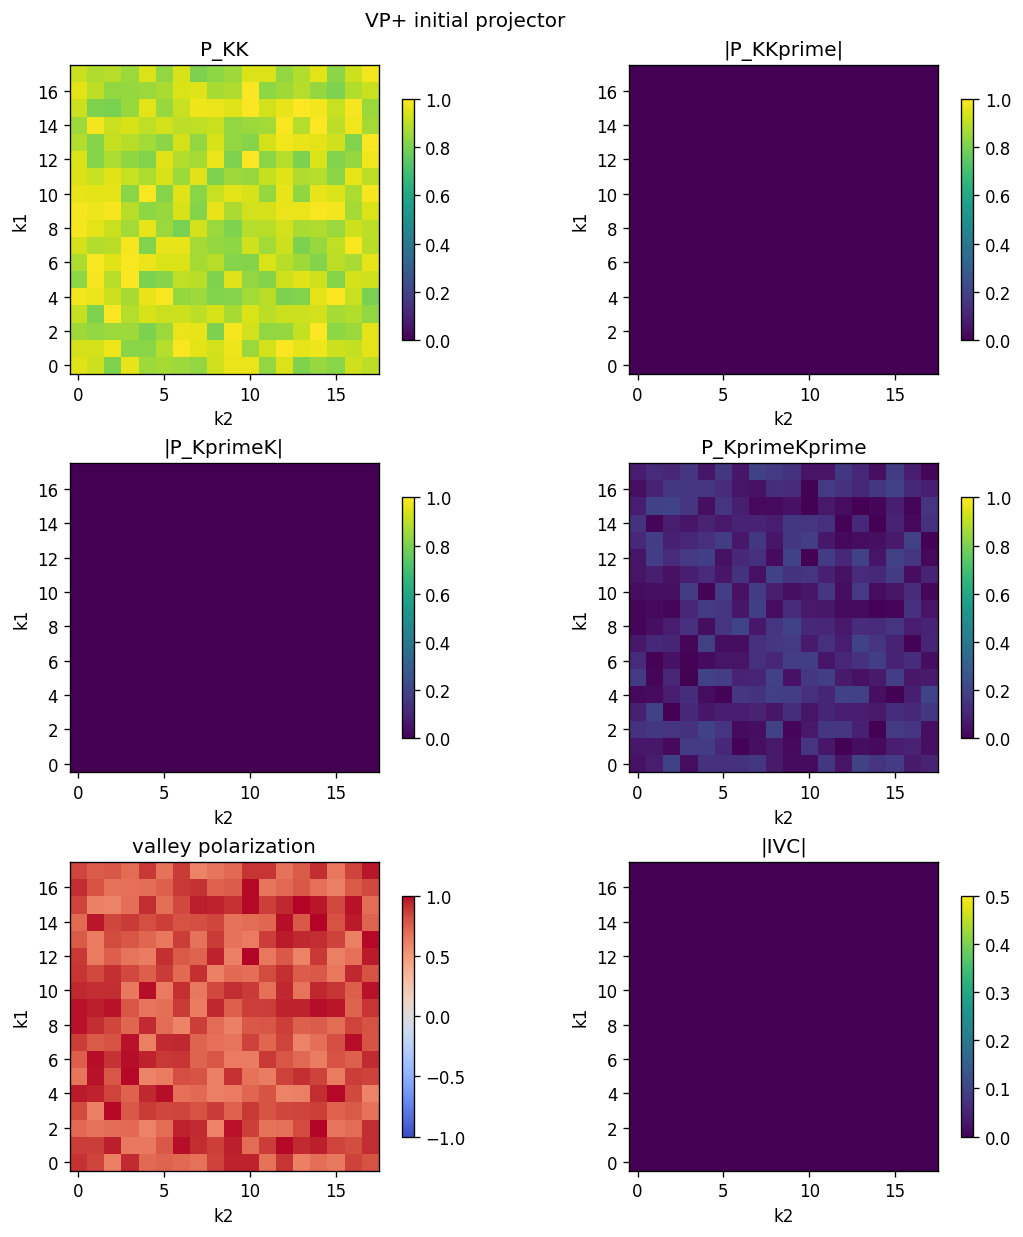

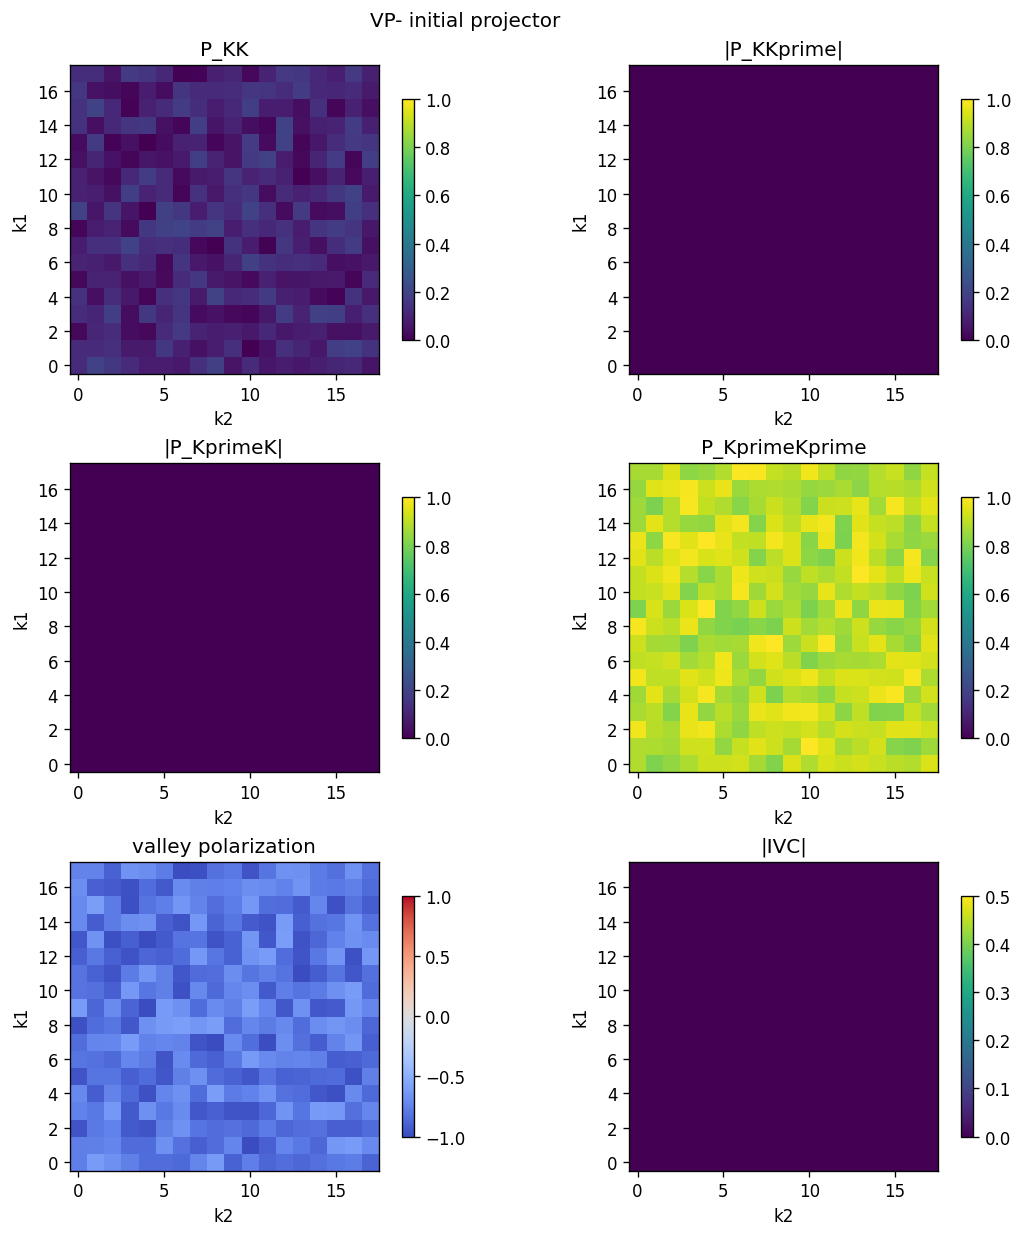

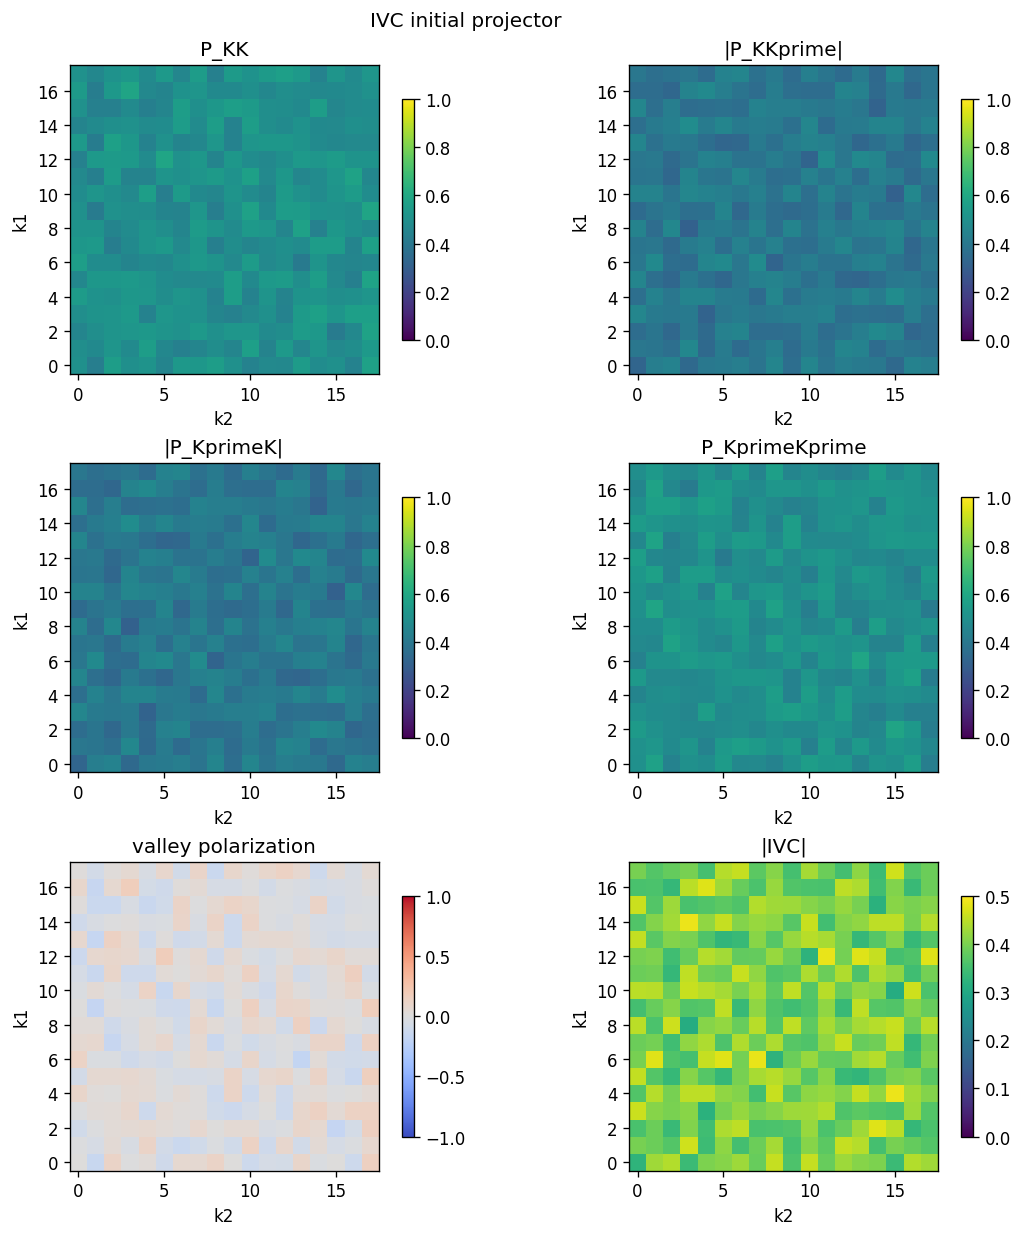

In [84]:

vp_plus_constraint = ValleyU1Constraint(active)
vp_minus_constraint = ValleyU1Constraint(active)
ivc_constraint = TPrimeConstraint(active)

P0_vp_plus, P_ordered_vp_plus, P_noise_vp_plus = noisy_initial_projector(
    "vp_plus",
    hf_params.random_seed + 1,
    vp_plus_constraint,
)
P0_vp_minus, P_ordered_vp_minus, P_noise_vp_minus = noisy_initial_projector(
    "vp_minus",
    hf_params.random_seed + 2,
    vp_minus_constraint,
)
P0_ivc, P_ordered_ivc, P_noise_ivc = noisy_initial_projector(
    "ivc",
    hf_params.random_seed + 3,
    ivc_constraint,
)

seed_rows = [
    seed_diagnostics_row("VP+ initial", P0_vp_plus, vp_plus_constraint),
    seed_diagnostics_row("VP- initial", P0_vp_minus, vp_minus_constraint),
    seed_diagnostics_row("IVC initial", P0_ivc, ivc_constraint),
]
display(pd.DataFrame(seed_rows))

for label, P0 in [("VP+ initial", P0_vp_plus), ("VP- initial", P0_vp_minus), ("IVC initial", P0_ivc)]:
    prefix = label.lower().replace(" ", "_").replace("+", "plus").replace("-", "minus")
    fig = plot_projector_diagnostics(P0, f"{label} projector")
    fig.savefig(result_dir / f"{prefix}.png", dpi=180)
    _display_and_close(fig)

## VP+ Valley-U(1) HF

This cell runs the K-biased valley-polarized reference. The `ValleyU1Constraint` removes intervalley density/operator blocks, but the fixed-per-k Aufbau update is not pinned to one valley; the biased noisy seed tests the basin of attraction.

The live callback refreshes this cell every `hf_update_every` iterations with a history tail and the combined 3x2 projector/order-parameter diagnostic. The final diagnostics report both projector idempotency and self-consistency residuals.


,iteration,energy,delta_energy,delta_P,idempotency_fro,idempotency_max,aufbau_residual,commutator,trace_error,constraint_error,direct_gap,indirect_gap,lambda,fallback,density_kind,mean_VP,mean_abs_IVC,max_abs_IVC
0,0,-11253.812101,NaN,NaN,2.481783,0.159989,2.922822,0.0,0.0,0.0,18.377788,15.512518,NaN,,mixed,0.802744,0.0,0.0
1,1,-12663.938933,-1410.126832,2.922822,0.000000,0.000000,0.000000,0.0,0.0,0.0,27.244592,25.241780,1.0,nonpositive_curvature_full_step,mixed,1.000000,0.0,0.0


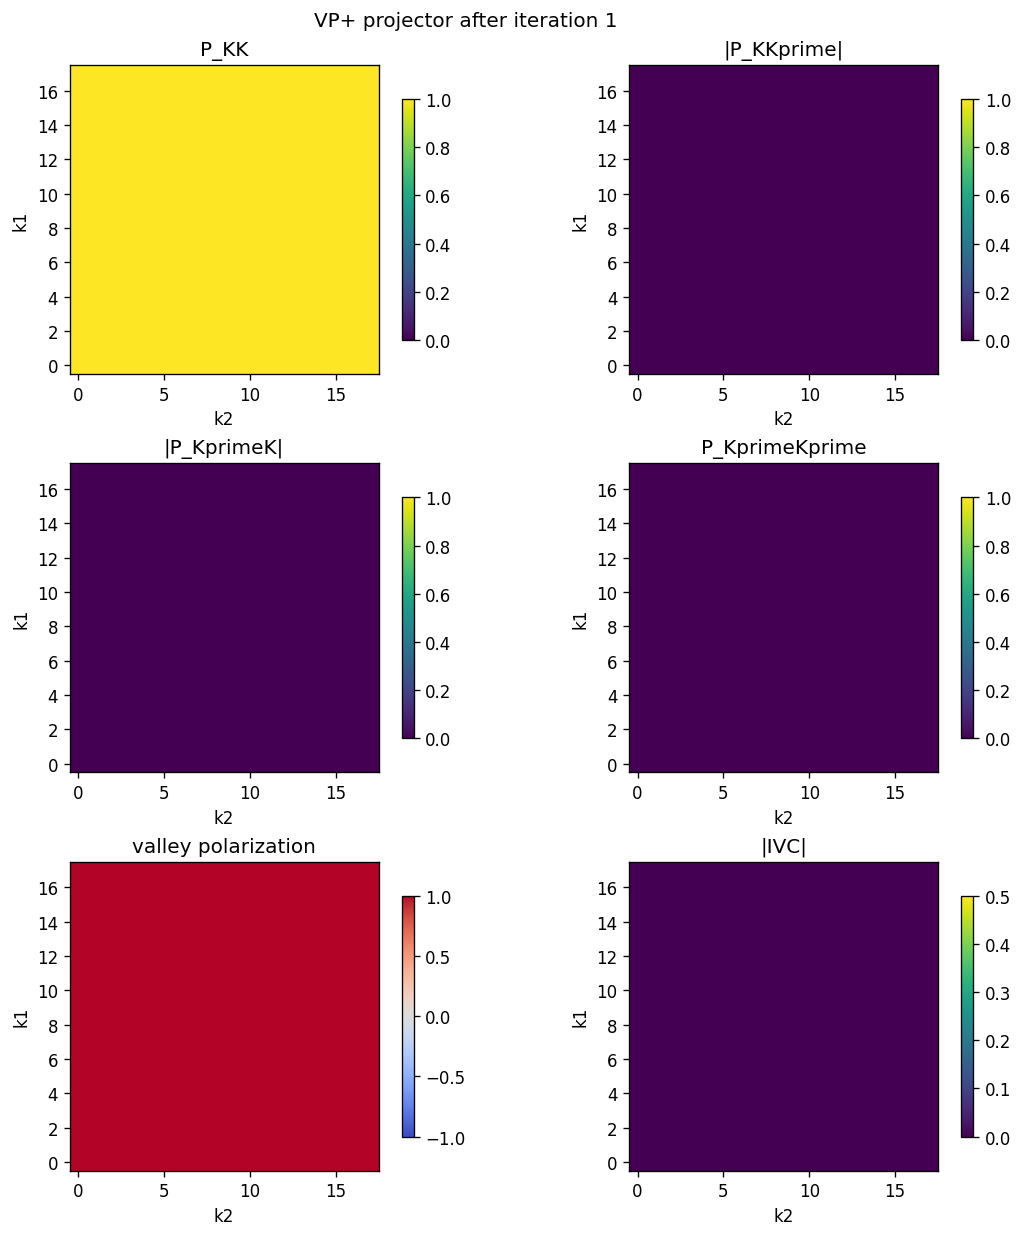

,iteration,energy,delta_energy,delta_P,idempotency_fro,idempotency_max,aufbau_residual,commutator,trace_error,constraint_error,direct_gap,indirect_gap,lambda,fallback,density_kind,mean_VP,mean_abs_IVC,max_abs_IVC
0,0,-11253.812101,NaN,NaN,2.481783,0.159989,2.922822,0.0,0.0,0.0,18.377788,15.512518,NaN,,mixed,0.802744,0.0,0.0
1,1,-12663.938933,-1410.126832,2.922822,0.000000,0.000000,0.000000,0.0,0.0,0.0,27.244592,25.241780,1.0,nonpositive_curvature_full_step,mixed,1.000000,0.0,0.0
2,2,-12663.938933,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,27.244592,25.241780,1.0,nonpositive_curvature_full_step,mixed,1.000000,0.0,0.0
3,3,-12663.938933,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,27.244592,25.241780,1.0,nonpositive_curvature_full_step,mixed,1.000000,0.0,0.0
4,3,-12663.938933,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,27.244592,25.241780,NaN,,final_idempotent,1.000000,0.0,0.0


VP+: energy=-12663.9389331, converged=True, iterations=3
  idempotency fro/max: 0.0 0.0
  residual/commutator: 0.0 0.0
  trace/constraint: 0.0 0.0
  direct/indirect gap: 27.244591969340103 25.241780025744387
  snapshots: [1]


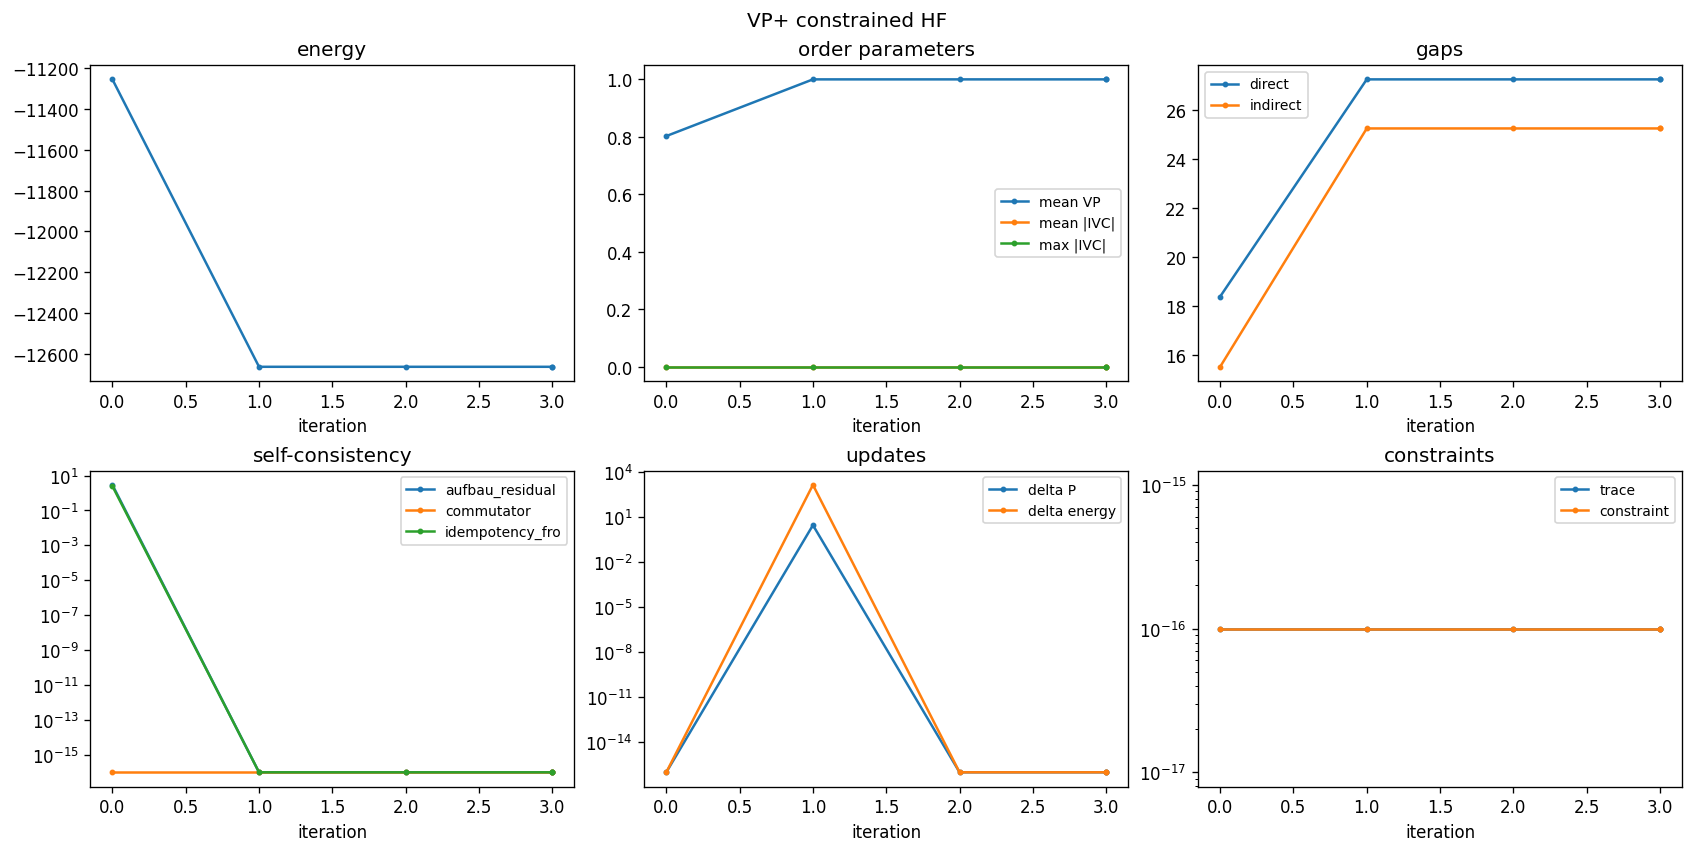

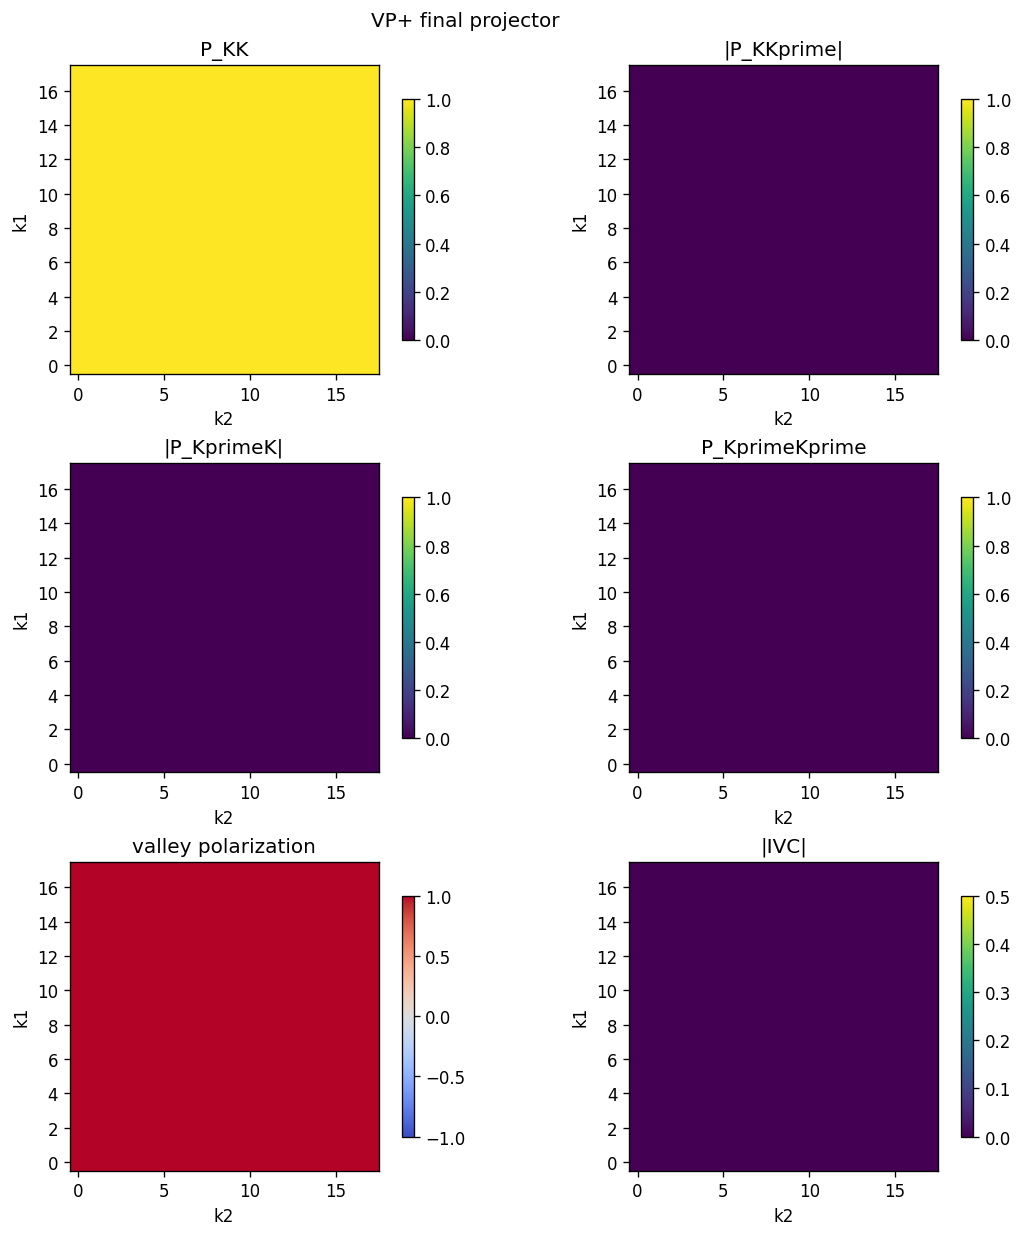

In [85]:

vp_plus, vp_plus_history = run_live_hf(
    "VP+",
    P0_vp_plus,
    vp_plus_constraint,
    "vp_plus_0p8_ordered_0p2_random",
    "vp_plus",
)

## VP- Valley-U(1) HF

This cell repeats the same U(1)-preserving solve in the Kprime-polarized sector. At `u_D = 0`, VP+ and VP- should become degenerate once all continuum, form-factor, and interaction conventions are sufficiently symmetric.

If the printed energy splitting remains visible, treat it as a convention or finite-cutoff diagnostic rather than a physical displacement-field effect. The live table and projector maps follow the same format as VP+.


,iteration,energy,delta_energy,delta_P,idempotency_fro,idempotency_max,aufbau_residual,commutator,trace_error,constraint_error,direct_gap,indirect_gap,lambda,fallback,density_kind,mean_VP,mean_abs_IVC,max_abs_IVC
0,0,-11259.878413,NaN,NaN,2.456982,0.159802,2.871882,0.0,0.0,0.0,17.907777,15.008886,NaN,,mixed,-0.802109,0.0,0.0
1,1,-12663.938932,-1404.060519,2.871882,0.000000,0.000000,0.000000,0.0,0.0,0.0,27.244592,25.241780,1.0,nonpositive_curvature_full_step,mixed,-1.000000,0.0,0.0


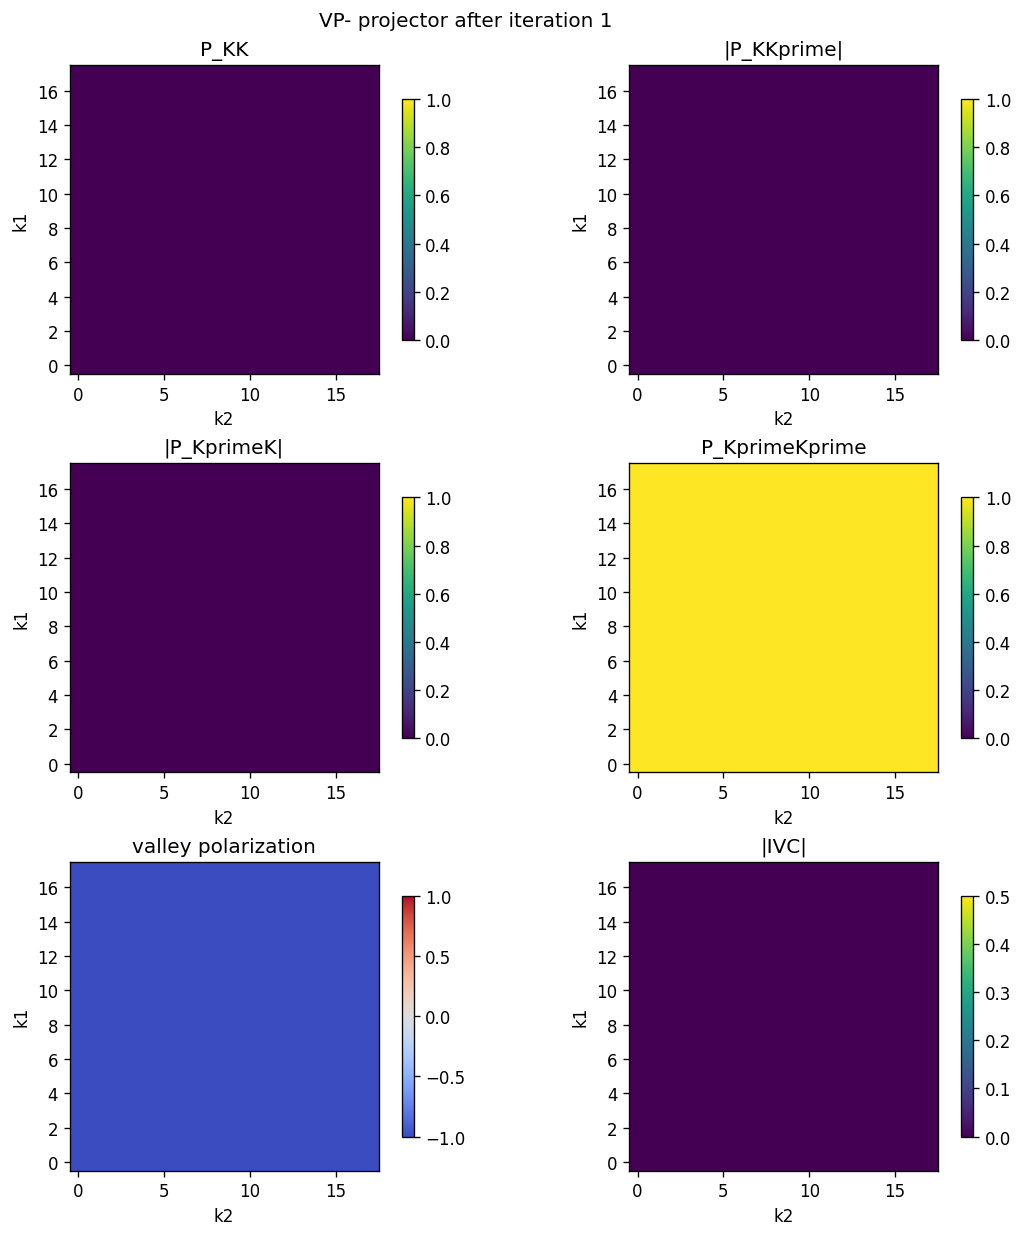

,iteration,energy,delta_energy,delta_P,idempotency_fro,idempotency_max,aufbau_residual,commutator,trace_error,constraint_error,direct_gap,indirect_gap,lambda,fallback,density_kind,mean_VP,mean_abs_IVC,max_abs_IVC
0,0,-11259.878413,NaN,NaN,2.456982,0.159802,2.871882,0.0,0.0,0.0,17.907777,15.008886,NaN,,mixed,-0.802109,0.0,0.0
1,1,-12663.938932,-1404.060519,2.871882,0.000000,0.000000,0.000000,0.0,0.0,0.0,27.244592,25.241780,1.0,nonpositive_curvature_full_step,mixed,-1.000000,0.0,0.0
2,2,-12663.938932,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,27.244592,25.241780,1.0,nonpositive_curvature_full_step,mixed,-1.000000,0.0,0.0
3,3,-12663.938932,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,27.244592,25.241780,1.0,nonpositive_curvature_full_step,mixed,-1.000000,0.0,0.0
4,3,-12663.938932,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,27.244592,25.241780,NaN,,final_idempotent,-1.000000,0.0,0.0


VP-: energy=-12663.9389323, converged=True, iterations=3
  idempotency fro/max: 0.0 0.0
  residual/commutator: 0.0 0.0
  trace/constraint: 0.0 0.0
  direct/indirect gap: 27.244591955456706 25.2417800003743
  snapshots: [1]


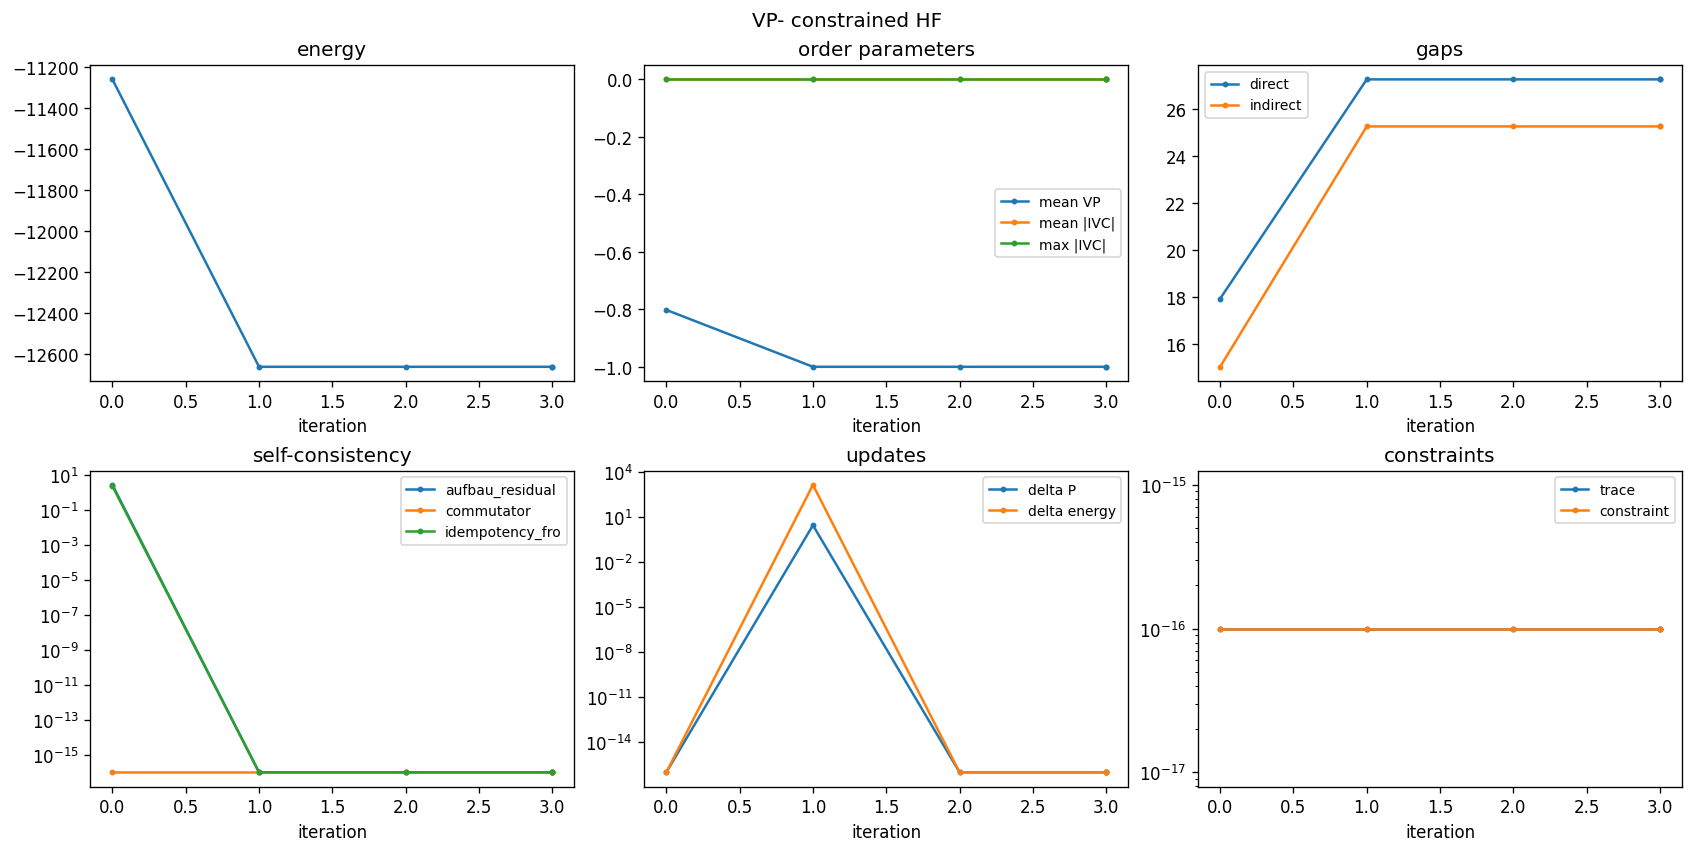

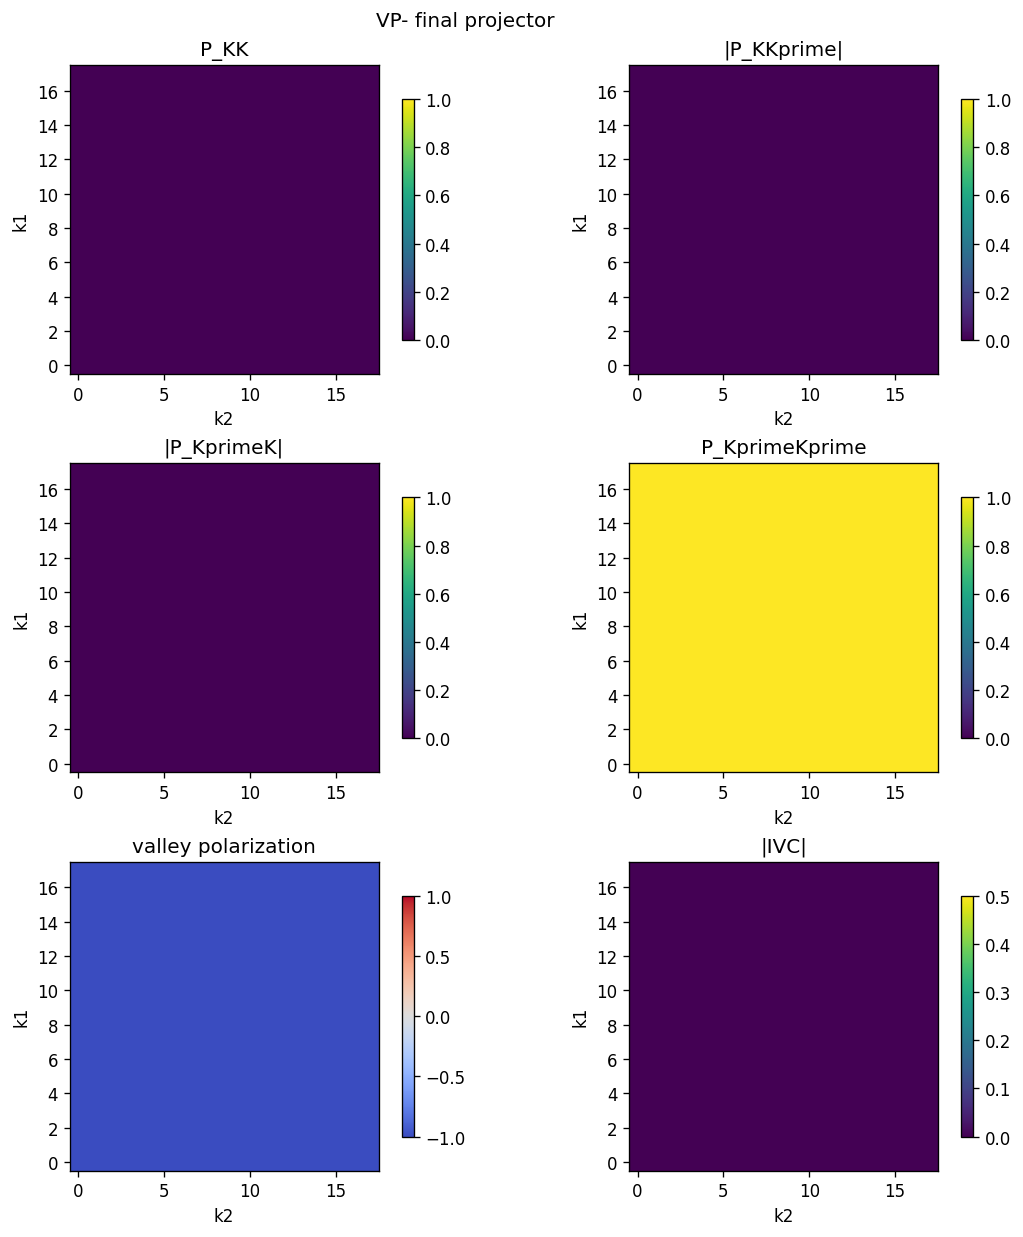

In [86]:

vp_minus, vp_minus_history = run_live_hf(
    "VP-",
    P0_vp_minus,
    vp_minus_constraint,
    "vp_minus_0p8_ordered_0p2_random",
    "vp_minus",
)

## Q=0 IVC T-Prime HF

This cell runs the Q=0 intervalley-coherent reference with the non-Kramers T-prime constraint. The seed carries explicit K/Kprime coherence, and the constraint relates the projector at `k` to the valley-swapped complex conjugate at `-k`.

The off-diagonal projector panels and `|IVC|` map are the main diagnostic for this run. The final idempotent projector is always reported, even when the residual says the idempotent projector is not yet a fully self-consistent HF fixed point.


,iteration,energy,delta_energy,delta_P,idempotency_fro,idempotency_max,aufbau_residual,commutator,trace_error,constraint_error,direct_gap,indirect_gap,lambda,fallback,density_kind,mean_VP,mean_abs_IVC,max_abs_IVC
69,69,-11767.400739,1.818989e-12,1.906878e-08,3.786160e-15,5.551115e-16,1.496676e-08,4.930333e-07,0.0,0.0,31.737198,16.885057,1.0,nonpositive_curvature_full_step,mixed,0.000000e+00,0.426403,0.5
70,70,-11767.400739,-9.094947e-12,1.496676e-08,3.667051e-15,4.440892e-16,1.174715e-08,3.869734e-07,0.0,0.0,31.737198,16.885057,1.0,nonpositive_curvature_full_step,mixed,-2.193033e-17,0.426403,0.5
71,71,-11767.400739,0.000000e+00,1.174715e-08,3.567438e-15,4.440892e-16,9.220135e-09,3.037287e-07,0.0,0.0,31.737198,16.885057,1.0,nonpositive_curvature_full_step,mixed,0.000000e+00,0.426403,0.5
72,72,-11767.400739,0.000000e+00,9.220135e-09,3.594044e-15,4.440892e-16,7.236725e-09,2.383914e-07,0.0,0.0,31.737198,16.885057,1.0,nonpositive_curvature_full_step,mixed,0.000000e+00,0.426403,0.5
73,73,-11767.400739,0.000000e+00,7.236725e-09,3.690820e-15,4.440892e-16,5.679981e-09,1.871093e-07,0.0,0.0,31.737198,16.885057,1.0,nonpositive_curvature_full_step,mixed,2.193033e-17,0.426403,0.5
74,74,-11767.400739,-3.637979e-12,5.679981e-09,3.347787e-15,3.330669e-16,4.458118e-09,1.468588e-07,0.0,0.0,31.737198,16.885057,1.0,nonpositive_curvature_full_step,mixed,-4.386066e-17,0.426403,0.5
75,75,-11767.400739,3.637979e-12,4.458118e-09,3.853744e-15,5.551115e-16,3.499100e-09,1.152670e-07,0.0,0.0,31.737198,16.885057,1.0,nonpositive_curvature_full_step,mixed,2.193033e-17,0.426403,0.5
76,76,-11767.400739,7.275958e-12,3.499100e-09,3.730004e-15,4.440892e-16,2.746383e-09,9.047107e-08,0.0,0.0,31.737198,16.885057,1.0,nonpositive_curvature_full_step,mixed,2.193033e-17,0.426403,0.5
77,77,-11767.400739,-7.275958e-12,2.746383e-09,3.546028e-15,4.440892e-16,2.155589e-09,7.100918e-08,0.0,0.0,31.737198,16.885057,1.0,nonpositive_curvature_full_step,mixed,2.193033e-17,0.426403,0.5
78,78,-11767.400739,0.000000e+00,2.155589e-09,3.697676e-15,4.440892e-16,1.691884e-09,5.573387e-08,0.0,0.0,31.737198,16.885057,1.0,nonpositive_curvature_full_step,mixed,0.000000e+00,0.426403,0.5


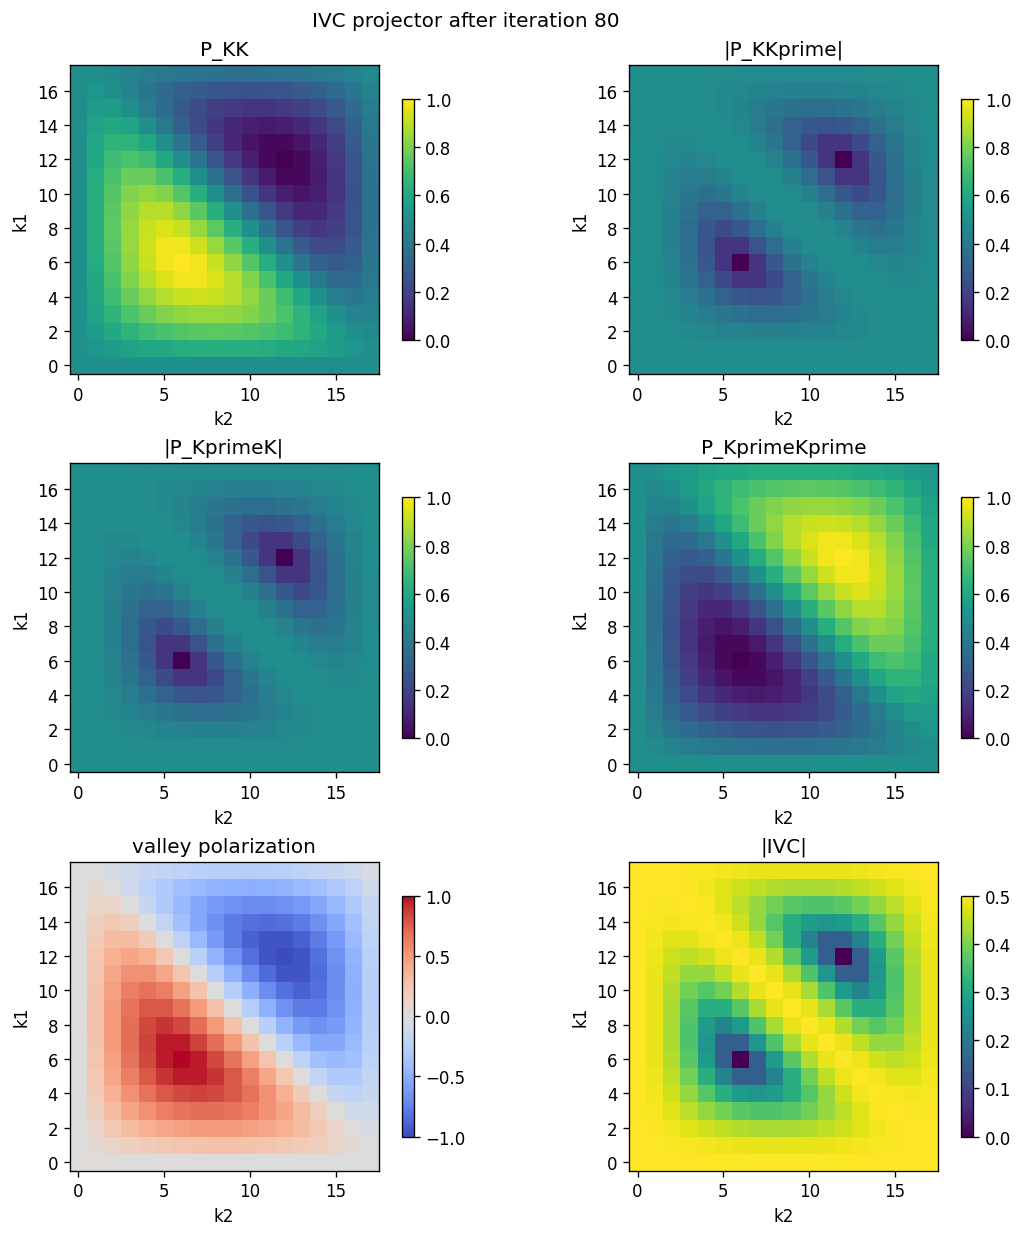

,iteration,energy,delta_energy,delta_P,idempotency_fro,idempotency_max,aufbau_residual,commutator,trace_error,constraint_error,direct_gap,indirect_gap,lambda,fallback,density_kind,mean_VP,mean_abs_IVC,max_abs_IVC
73,73,-11767.400739,0.000000e+00,7.236725e-09,3.690820e-15,4.440892e-16,5.679981e-09,1.871093e-07,0.0,0.0,31.737198,16.885057,1.0,nonpositive_curvature_full_step,mixed,2.193033e-17,0.426403,0.5
74,74,-11767.400739,-3.637979e-12,5.679981e-09,3.347787e-15,3.330669e-16,4.458118e-09,1.468588e-07,0.0,0.0,31.737198,16.885057,1.0,nonpositive_curvature_full_step,mixed,-4.386066e-17,0.426403,0.5
75,75,-11767.400739,3.637979e-12,4.458118e-09,3.853744e-15,5.551115e-16,3.499100e-09,1.152670e-07,0.0,0.0,31.737198,16.885057,1.0,nonpositive_curvature_full_step,mixed,2.193033e-17,0.426403,0.5
76,76,-11767.400739,7.275958e-12,3.499100e-09,3.730004e-15,4.440892e-16,2.746383e-09,9.047107e-08,0.0,0.0,31.737198,16.885057,1.0,nonpositive_curvature_full_step,mixed,2.193033e-17,0.426403,0.5
77,77,-11767.400739,-7.275958e-12,2.746383e-09,3.546028e-15,4.440892e-16,2.155589e-09,7.100918e-08,0.0,0.0,31.737198,16.885057,1.0,nonpositive_curvature_full_step,mixed,2.193033e-17,0.426403,0.5
78,78,-11767.400739,0.000000e+00,2.155589e-09,3.697676e-15,4.440892e-16,1.691884e-09,5.573387e-08,0.0,0.0,31.737198,16.885057,1.0,nonpositive_curvature_full_step,mixed,0.000000e+00,0.426403,0.5
79,79,-11767.400739,1.818989e-12,1.691884e-09,3.686475e-15,3.376612e-16,1.327931e-09,4.374456e-08,0.0,0.0,31.737198,16.885057,1.0,nonpositive_curvature_full_step,mixed,0.000000e+00,0.426403,0.5
80,80,-11767.400739,9.094947e-12,1.327931e-09,3.565578e-15,4.440892e-16,1.042270e-09,3.433435e-08,0.0,0.0,31.737198,16.885057,1.0,nonpositive_curvature_full_step,mixed,0.000000e+00,0.426403,0.5
81,81,-11767.400739,-1.273293e-11,1.042270e-09,3.619410e-15,3.330669e-16,8.180598e-10,2.694844e-08,0.0,0.0,31.737198,16.885057,1.0,nonpositive_curvature_full_step,mixed,0.000000e+00,0.426403,0.5
82,82,-11767.400739,-1.818989e-12,8.180598e-10,3.561142e-15,4.440892e-16,6.420809e-10,2.115136e-08,0.0,0.0,31.737198,16.885057,1.0,nonpositive_curvature_full_step,mixed,0.000000e+00,0.426403,0.5


IVC: energy=-11767.4007392, converged=True, iterations=86
  idempotency fro/max: 3.529292087459079e-15 3.3306690738754696e-16
  residual/commutator: 1.9125547604992383e-10 6.300317317346072e-09
  trace/constraint: 0.0 0.0
  direct/indirect gap: 31.73719807542037 16.885056617823114
  snapshots: [1, 10, 20, 30, 40, 50, 60, 70, 80]


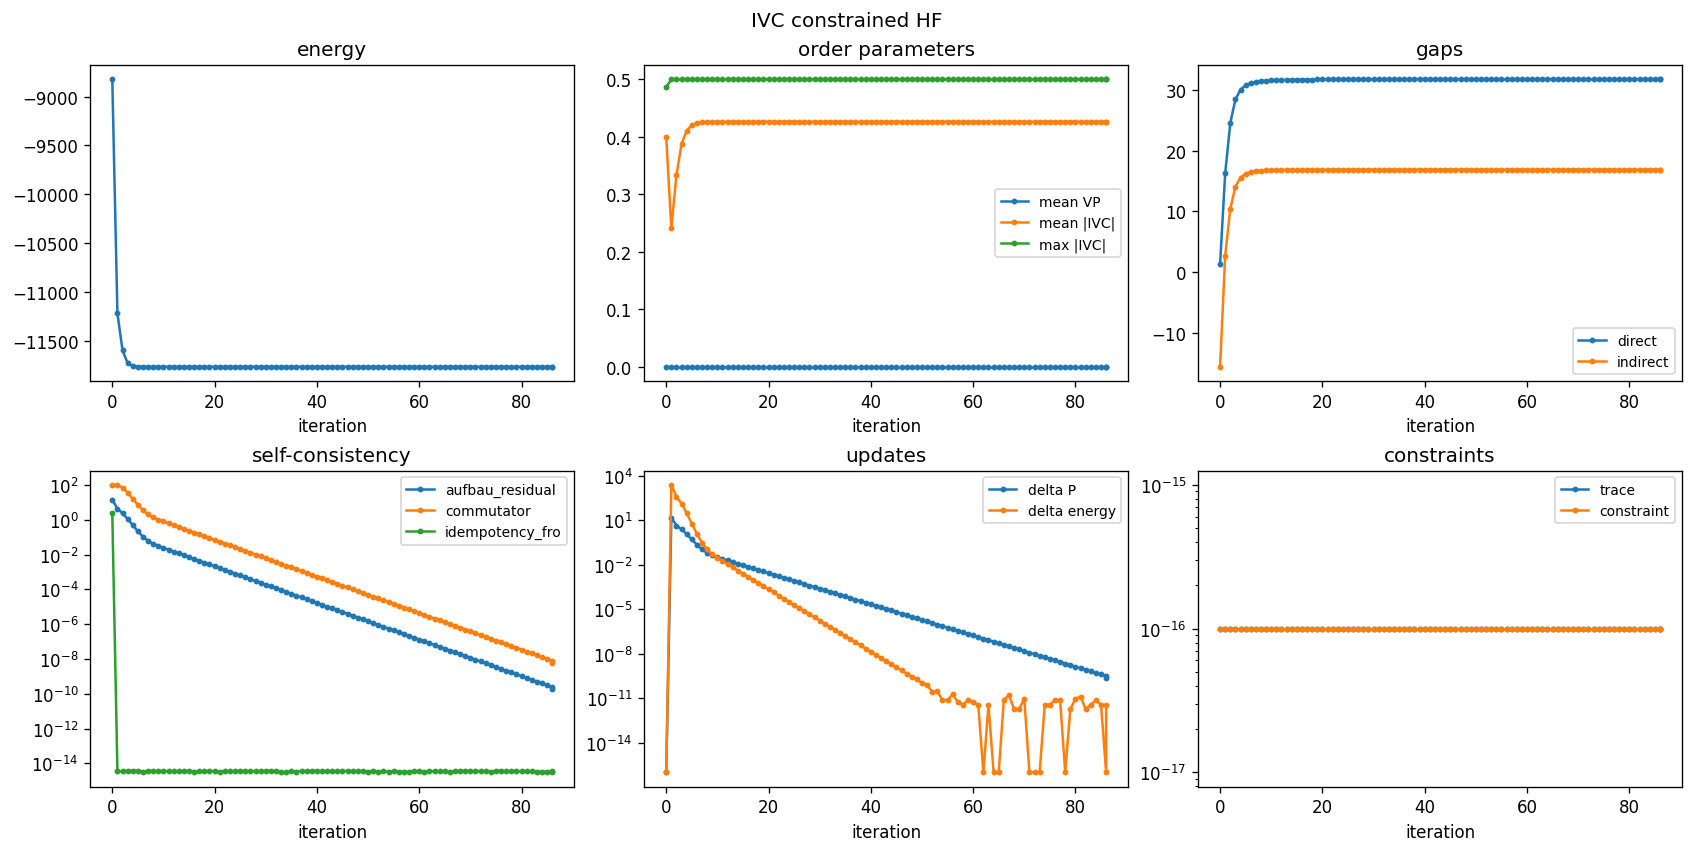

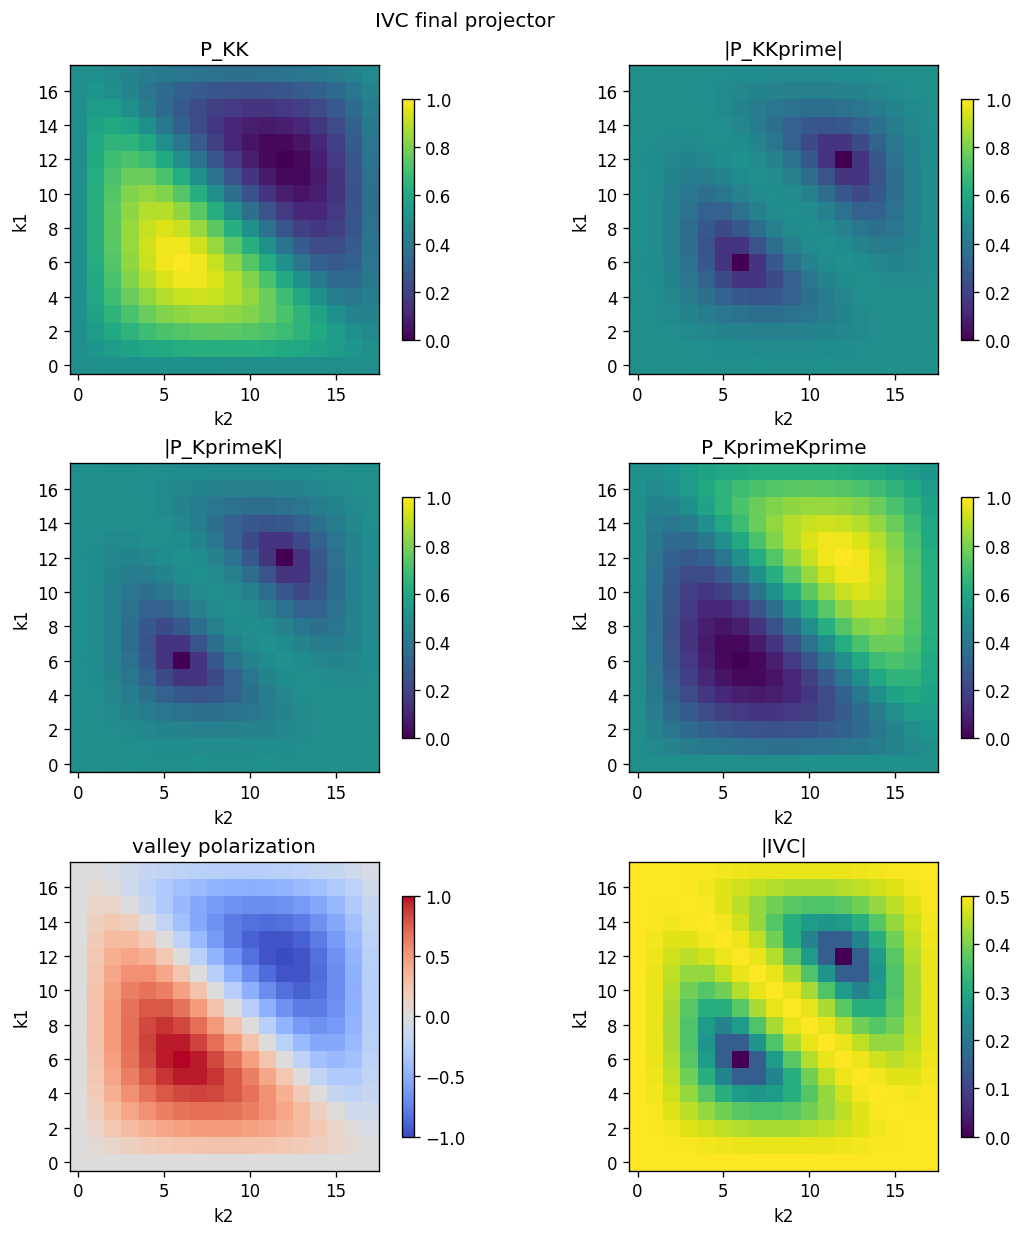

In [87]:

ivc, ivc_history = run_live_hf(
    "IVC",
    P0_ivc,
    ivc_constraint,
    "ivc_0p8_ordered_0p2_random",
    "ivc",
)

## Finite-Q IVC Active Frame

The Q=0 references above remain the source for the convex trial Hamiltonian and charge response. This finite-Q branch is built as a separate active frame so we can compare the IVC HF energy cost without changing the `c_G` workflow.

The default branch is Taige IVC-, `Q = kappa_plus - kappa_minus`. The symmetric active frame uses physical momenta `K: k-Q/2` and `Kprime: k+Q/2`; the unfolded half-shift is required to preserve the non-Kramers T-prime relation in the active frame.


In [88]:

finite_q_enabled = True
finite_q_branch = "Taige IVC-"

if finite_q_enabled:
    finite_q = ContinuumFiniteQParams(
        enabled=True,
        q_coord=taige_ivc_minus_q_coord(n_k),
        half_shift_coord=taige_ivc_minus_half_shift_coord(n_k),
    )
else:
    finite_q = ContinuumFiniteQParams(enabled=False, q_coord=(0, 0))

finite_q_metadata = finite_q_shift_metadata(finite_q, bundle.grid)

print("finite_q_enabled:", finite_q_enabled)
print("finite_q_branch:", finite_q_branch)
print("finite_q:", finite_q)
print("finite_q_shift:", finite_q_metadata)

VP+ : -12663.9389331
VP- : -12663.9389323
IVC : -11767.4007392
VP splitting E(VP+) - E(VP-): -7.766284397803247e-07
vp_plus {'scalar_norm': 978.2857883698399, 'traceless_norm': 630.091220395387, 'valley_diagonal_norm': 1163.6399914689018, 'intervalley_norm': 0.0, 'hermiticity_error': 0.0}
vp_minus {'scalar_norm': 978.2857883571695, 'traceless_norm': 630.0912202770645, 'valley_diagonal_norm': 1163.6399913941807, 'intervalley_norm': 0.0, 'hermiticity_error': 0.0}
ivc {'scalar_norm': 994.1254894683058, 'traceless_norm': 421.18540407470084, 'valley_diagonal_norm': 1015.2175881780084, 'intervalley_norm': 367.44507354187755, 'hermiticity_error': 0.0}


## Finite-Q Density Vertices

This cell builds the finite-Q active basis, form factors, and HF backend. The interaction parameters are intentionally the same as the Q=0 run, so any energy difference comes from the shifted active frame and the self-consistent IVC solution rather than from a changed Coulomb kernel.

The `source_index` and `source_shift` diagnostics check that the finite-Q active blocks really use shifted physical momenta. The `q=0` density vertex should still be the identity in the active frame.


In [ ]:

if finite_q_enabled:
    finite_q_bundle = build_continuum_bundle(
        model=model,
        grid=grid_params,
        interaction=interaction,
        finite_q=finite_q,
    )
    finite_q_active = finite_q_bundle.active
    finite_q_vertices = finite_q_bundle.vertices
    finite_q_backend = finite_q_bundle.backend

    finite_iq0 = finite_q_vertices.q_shifts.index((0, 0))
    finite_q0_identity_error = np.max(
        np.abs(finite_q_vertices.lambda_blocks[finite_iq0, 0] - np.eye(finite_q_active.dim))
    )

    print("finite-Q grid blocks:", finite_q_active.n_k)
    print("finite-Q h0:", finite_q_active.h0.shape)
    print("finite-Q lambda blocks:", finite_q_vertices.lambda_blocks.shape)
    print("finite-Q source index differs from active index:", bool(np.any(
        finite_q_active.source_index != np.arange(finite_q_active.n_k)[:, None]
    )))
    print("finite-Q nonzero source shifts:", int(np.count_nonzero(finite_q_active.source_shift)))
    print("finite-Q q=0 identity error:", float(finite_q0_identity_error))
else:
    finite_q_bundle = None
    finite_q_active = None
    finite_q_vertices = None
    finite_q_backend = None
    print("finite-Q branch disabled")

## Finite-Q IVC Initial Projector

This seed uses the same 0.8 ordered / 0.2 random-noisy recipe as the Q=0 IVC run, but it is built in the finite-Q active frame. The projector panels should show intervalley coherence in that shifted frame.


In [ ]:

if finite_q_enabled:
    finite_q_ivc_constraint = TPrimeConstraint(finite_q_active)
    P0_finite_q_ivc, P_ordered_finite_q_ivc, P_noise_finite_q_ivc = noisy_initial_projector(
        "finite_q_ivc",
        hf_params.random_seed + 4,
        finite_q_ivc_constraint,
        active_for_seed=finite_q_active,
        hf_for_seed=hf_params,
    )
    display(pd.DataFrame([
        seed_diagnostics_row(
            "finite-Q IVC initial",
            P0_finite_q_ivc,
            finite_q_ivc_constraint,
            active_for_plot=finite_q_active,
        )
    ]))
    fig = plot_projector_diagnostics(
        P0_finite_q_ivc,
        "finite-Q IVC initial projector",
        active_for_plot=finite_q_active,
    )
    fig.savefig(result_dir / "finite_q_ivc_initial.png", dpi=180)
    _display_and_close(fig)
else:
    finite_q_ivc_constraint = None
    P0_finite_q_ivc = None

## Finite-Q IVC T-Prime HF

This cell solves the finite-Q IVC reference with the same T-prime constrained HF loop used above. The result is for energy comparison only; it is not inserted into the Q=0 convex Hamiltonian path below.


In [ ]:

if finite_q_enabled:
    finite_q_ivc, finite_q_ivc_history = run_live_hf(
        "finite-Q IVC",
        P0_finite_q_ivc,
        finite_q_ivc_constraint,
        "finite_q_ivc_0p8_ordered_0p2_random",
        "finite_q_ivc",
        backend_for_run=finite_q_backend,
        active_for_run=finite_q_active,
        hf_for_run=hf_params,
    )
else:
    finite_q_ivc = None
    finite_q_ivc_history = pd.DataFrame()

## Q=0 Versus Finite-Q IVC Energy Cost

This comparison uses the lower of the two Q=0 VP energies as the VP reference baseline. Energies are divided by the number of moire momentum blocks, giving energy per moire unit cell in the same units as the continuum Hamiltonian.


In [ ]:

energy_norm = float(backend.n_blocks)
finite_q_energy_norm = np.nan if finite_q_ivc is None else float(finite_q_backend.n_blocks)

vp_energy_by_name = {"VP+": vp_plus.energy, "VP-": vp_minus.energy}
vp_reference_name = min(vp_energy_by_name, key=vp_energy_by_name.get)
E_VP_reference_per_cell = vp_energy_by_name[vp_reference_name] / energy_norm
E_IVC_Q0_per_cell = ivc.energy / energy_norm
E_IVC_finite_Q_per_cell = (
    np.nan if finite_q_ivc is None else finite_q_ivc.energy / finite_q_energy_norm
)
Delta_IVC_Q0_vs_VP_per_cell = E_IVC_Q0_per_cell - E_VP_reference_per_cell
Delta_IVC_finite_Q_vs_VP_per_cell = E_IVC_finite_Q_per_cell - E_VP_reference_per_cell
Delta_finite_Q_minus_Q0_per_cell = E_IVC_finite_Q_per_cell - E_IVC_Q0_per_cell

ivc_energy_comparison = pd.DataFrame(
    [
        {
            "quantity": "E_VP_reference_per_cell",
            "value": E_VP_reference_per_cell,
            "reference": vp_reference_name,
        },
        {
            "quantity": "E_IVC_Q0_per_cell",
            "value": E_IVC_Q0_per_cell,
            "reference": "",
        },
        {
            "quantity": "E_IVC_finite_Q_per_cell",
            "value": E_IVC_finite_Q_per_cell,
            "reference": finite_q_branch if finite_q_enabled else "disabled",
        },
        {
            "quantity": "Delta_IVC_Q0_vs_VP_per_cell",
            "value": Delta_IVC_Q0_vs_VP_per_cell,
            "reference": vp_reference_name,
        },
        {
            "quantity": "Delta_IVC_finite_Q_vs_VP_per_cell",
            "value": Delta_IVC_finite_Q_vs_VP_per_cell,
            "reference": vp_reference_name,
        },
        {
            "quantity": "Delta_finite_Q_minus_Q0_per_cell",
            "value": Delta_finite_Q_minus_Q0_per_cell,
            "reference": "",
        },
    ]
)
ivc_energy_comparison.to_csv(result_dir / "ivc_q0_vs_finite_q_energy_comparison.csv", index=False)
display(ivc_energy_comparison)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), constrained_layout=True)
energy_plot = ivc_energy_comparison.iloc[:3]
axes[0].bar(energy_plot["quantity"], energy_plot["value"])
axes[0].tick_params(axis="x", rotation=35)
axes[0].set_ylabel("energy per cell")
axes[0].set_title("absolute energies")

cost_plot = ivc_energy_comparison.iloc[3:]
axes[1].bar(cost_plot["quantity"], cost_plot["value"])
axes[1].tick_params(axis="x", rotation=35)
axes[1].set_ylabel("energy per cell")
axes[1].set_title("IVC costs")
fig.savefig(result_dir / "ivc_q0_vs_finite_q_energy_costs.png", dpi=180)
plt.show()

## Reference Energies And Channel Diagnostics

The VP splitting printed below is a convention/truncation check. At `u_D = 0`, a nonzero value indicates the finite active-space/form-factor setup or the selected mesh controls are still breaking the expected VP+/VP- equivalence. The finite-Q IVC energy, if enabled, is printed for comparison but is not included in `refs`.


In [ ]:

refs = SymmetricHFReferences(vp_plus=vp_plus, vp_minus=vp_minus, ivc=ivc, n_occ_per_k=hf_params.n_occ_per_k)
energies = {
    "VP+": vp_plus.energy,
    "VP-": vp_minus.energy,
    "IVC": ivc.energy,
}
for key, value in energies.items():
    print(f"{key:4s}: {value:.12g}")
if finite_q_ivc is not None:
    print(f"finite-Q IVC: {finite_q_ivc.energy:.12g}")
print("VP splitting E(VP+) - E(VP-):", energies["VP+"] - energies["VP-"])

for name, diag in reference_diagnostics(refs).items():
    print(name, diag.model_dump(mode="json"))

## Symmetric Convex Trial Hamiltonian Path

The HF references are now fixed, so this is the first place where the `theta` path and global IVC phase are needed. Changing these values recomputes the trial Hamiltonian path and `K(theta)` without rerunning the three HF solves.


In [89]:

n_theta = 41
endpoint_eps = 1e-4
phi = 0.0

print("n_theta:", n_theta)
print("endpoint_eps:", endpoint_eps)
print("phi:", phi)

n_theta: 41
endpoint_eps: 0.0001
phi: 0.0


This cell builds the convex Hamiltonian path from the three raw HF Hamiltonians, diagonalizes each point into a fixed-occupation projector, embeds the active projector back into the continuum Bloch basis, and computes the dimensionless response kernel `K(theta)` and coefficient `c_G`.


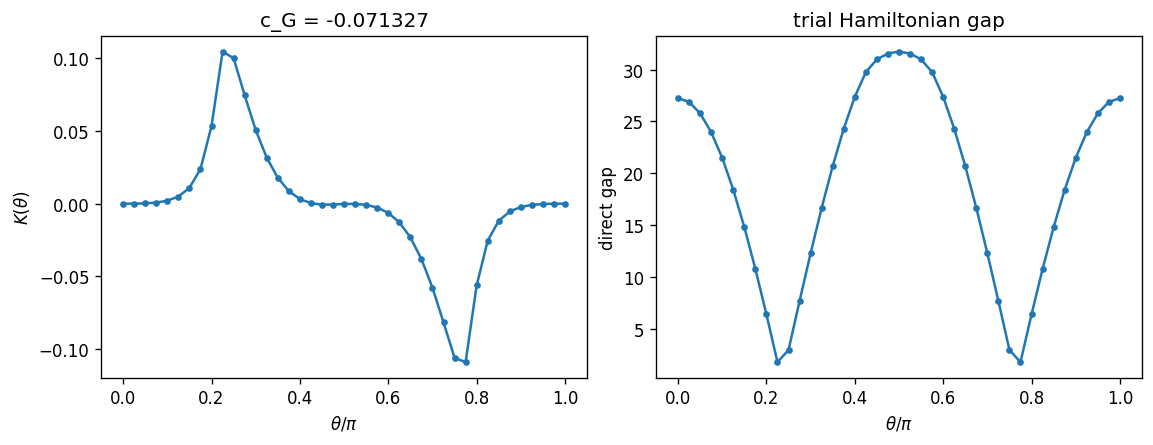

cG: -0.07132696887553412


In [90]:

theta_nodes = np.linspace(endpoint_eps, np.pi - endpoint_eps, n_theta)
projectors_flat, path_diagnostics = symmetric_convex_path(refs, theta_nodes, phi=phi)
projectors = projectors_flat.reshape(n_theta, n_k, n_k, active.dim, active.dim)
if active.dim != 2:
    raise ValueError("charge-response cell currently expects one active band per valley")
basis_frames = active_basis_frames(active).reshape(n_k, n_k, -1, active.dim)
response = k_theta_from_projectors_with_basis(projectors, theta_nodes, basis_frames)

gaps = np.array([row.direct_gap_min for row in path_diagnostics])
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6), constrained_layout=True)
axes[0].plot(response.theta / np.pi, response.K, marker="o", ms=3)
axes[0].set_xlabel(r"$\theta/\pi$")
axes[0].set_ylabel(r"$K(\theta)$")
axes[0].set_title(f"c_G = {response.cG:.6g}")
axes[1].plot(theta_nodes / np.pi, gaps, marker="o", ms=3)
axes[1].set_xlabel(r"$\theta/\pi$")
axes[1].set_ylabel("direct gap")
axes[1].set_title("trial Hamiltonian gap")
fig.savefig(result_dir / "convex_path_response.png", dpi=180)
plt.show()
print("cG:", response.cG)

This cell evaluates the physical projected interacting Hamiltonian in each trial Slater determinant along the convex path. The energy is computed with the HF backend energy functional, `E[P] = Tr(h0 P) + E_H[P] + E_F[P]`, using the trial projector `P(theta)` as the density; no trial source-field or penalty energy is included. The plotted values are divided by the number of moire momentum blocks, so the units are energy per moire unit cell.


,theta,theta_over_pi,energy_total_per_cell,energy_relative_per_cell,energy_one_body_per_cell,energy_hartree_per_cell,energy_fock_per_cell
0,0.000100,0.000032,-39.086231,0.000000,-15.678103,0.903646,-24.311774
1,0.078635,0.025030,-39.086181,0.000051,-15.678110,0.903647,-24.311718
2,0.157170,0.050029,-39.085400,0.000831,-15.678208,0.903661,-24.310853
3,0.235704,0.075027,-39.081830,0.004401,-15.678692,0.903729,-24.306868
4,0.314239,0.100025,-39.071392,0.014839,-15.680277,0.903954,-24.295070


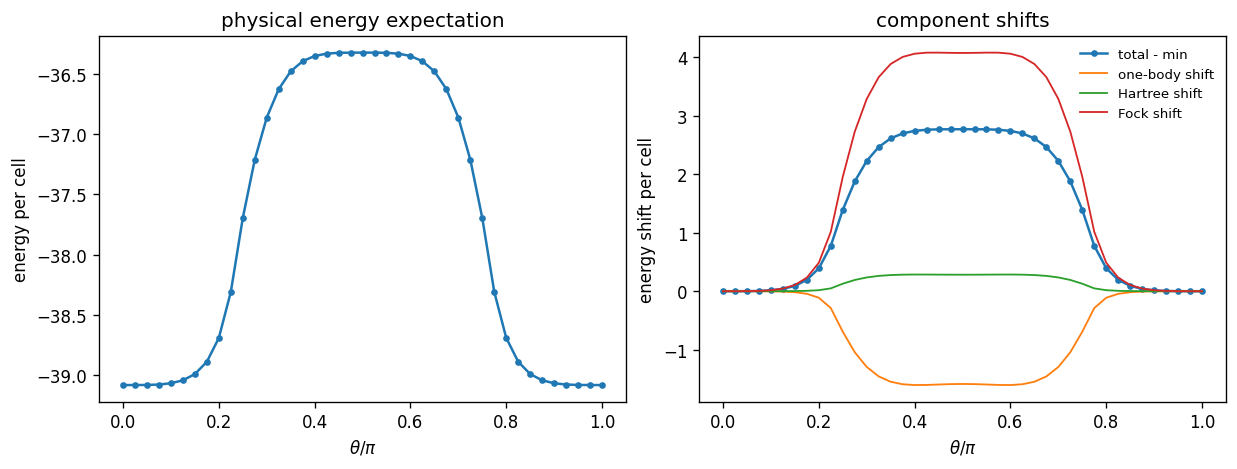

energy per cell min: -39.08623127487182
energy per cell max: -36.31913808404652
energy per cell range: 2.7670931908252996


In [91]:

trial_energy_components = [bundle.backend.energy(P_theta) for P_theta in projectors_flat]
energy_norm = float(bundle.backend.n_blocks)
trial_energy_total_per_cell = np.array([item.total for item in trial_energy_components]) / energy_norm
trial_energy_one_body_per_cell = np.array([item.one_body for item in trial_energy_components]) / energy_norm
trial_energy_hartree_per_cell = np.array([item.hartree for item in trial_energy_components]) / energy_norm
trial_energy_fock_per_cell = np.array([item.fock for item in trial_energy_components]) / energy_norm
trial_energy_relative_per_cell = trial_energy_total_per_cell - float(np.min(trial_energy_total_per_cell))

trial_energy_df = pd.DataFrame(
    {
        "theta": theta_nodes,
        "theta_over_pi": theta_nodes / np.pi,
        "energy_total_per_cell": trial_energy_total_per_cell,
        "energy_relative_per_cell": trial_energy_relative_per_cell,
        "energy_one_body_per_cell": trial_energy_one_body_per_cell,
        "energy_hartree_per_cell": trial_energy_hartree_per_cell,
        "energy_fock_per_cell": trial_energy_fock_per_cell,
    }
)
trial_energy_df.to_csv(result_dir / "trial_physical_energy_theta.csv", index=False)
display(trial_energy_df.head())

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.8), constrained_layout=True)
axes[0].plot(theta_nodes / np.pi, trial_energy_total_per_cell, marker="o", ms=3)
axes[0].set_xlabel(r"$\theta/\pi$")
axes[0].set_ylabel("energy per cell")
axes[0].set_title("physical energy expectation")
axes[1].plot(theta_nodes / np.pi, trial_energy_relative_per_cell, marker="o", ms=3, label="total - min")
axes[1].plot(theta_nodes / np.pi, trial_energy_one_body_per_cell - trial_energy_one_body_per_cell[0], linewidth=1.1, label="one-body shift")
axes[1].plot(theta_nodes / np.pi, trial_energy_hartree_per_cell - trial_energy_hartree_per_cell[0], linewidth=1.1, label="Hartree shift")
axes[1].plot(theta_nodes / np.pi, trial_energy_fock_per_cell - trial_energy_fock_per_cell[0], linewidth=1.1, label="Fock shift")
axes[1].set_xlabel(r"$\theta/\pi$")
axes[1].set_ylabel("energy shift per cell")
axes[1].set_title("component shifts")
axes[1].legend(frameon=False, fontsize=8)
fig.savefig(result_dir / "trial_physical_energy_theta.png", dpi=180)
plt.show()

print("energy per cell min:", float(np.min(trial_energy_total_per_cell)))
print("energy per cell max:", float(np.max(trial_energy_total_per_cell)))
print("energy per cell range:", float(np.ptp(trial_energy_total_per_cell)))

## Post-HF Texture Controls

The domain-wall texture parameters enter only after `K(theta)` is known. Edit `R` and `w` here to recompute the radial texture and charge density from the already computed Q=0 HF references and convex path.

This cell does not rerun continuum bands, density vertices, Q=0 HF, or finite-Q IVC HF.


In [ ]:

R = 20.0
w = 3.0
winding = 1

domain_wall = DomainWallParams(radius=R, width=w, winding=winding)
r_max = max(2.0 * R, R + 8.0 * w)
r = np.linspace(max(1e-6, r_max / 800.0), r_max, 800)
profile = charge_density_radial(r, response.theta, response.K, domain_wall)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6), constrained_layout=True)
axes[0].plot(profile.r, profile.theta / np.pi)
axes[0].set_xlabel("r / a_M")
axes[0].set_ylabel(r"$\theta(r)/\pi$")
axes[0].set_title(f"R={R:g}, w={w:g}")
axes[1].plot(profile.r, profile.rho_dimless)
axes[1].set_xlabel("r / a_M")
axes[1].set_ylabel(r"$\rho a_M^2$")
axes[1].set_title("dimensionless charge density")
fig.savefig(result_dir / "charge_profile.png", dpi=180)
plt.show()

integrated_charge = float(np.trapezoid(2.0 * np.pi * profile.r * profile.rho_dimless, profile.r))
print("cG:", response.cG)
print("integrated radial charge:", integrated_charge)

This cell maps the same circular domain-wall profile onto a two-dimensional real-space grid. The charge density is still reported in dimensionless moire units, so the plotted value is `rho * a_M^2`; changing `R`, `w`, or `winding` in the previous cell changes this plot without rerunning HF.


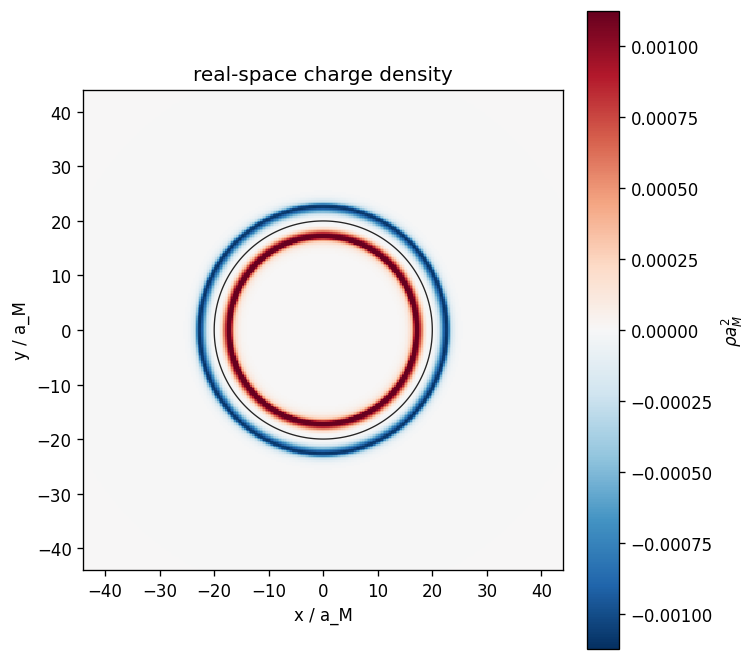

charge density 2D grid: (301, 301)
integrated 2D charge: -0.026918191736928505


In [92]:

charge_grid_size = 301
charge_plot_r_max = r_max

x = np.linspace(-charge_plot_r_max, charge_plot_r_max, charge_grid_size)
y = np.linspace(-charge_plot_r_max, charge_plot_r_max, charge_grid_size)
xx, yy = np.meshgrid(x, y, indexing="xy")
rr = np.sqrt(xx**2 + yy**2)
grid_profile = charge_density_radial(
    rr,
    response.theta,
    response.K,
    domain_wall,
    r_min=charge_plot_r_max / max(charge_grid_size, 1),
)
rho_xy = grid_profile.rho_dimless

rho_vmax = float(np.nanpercentile(np.abs(rho_xy), 99.0))
if not np.isfinite(rho_vmax) or rho_vmax <= 0.0:
    rho_vmax = 1.0

fig, ax = plt.subplots(figsize=(6.2, 5.4), constrained_layout=True)
im = ax.imshow(
    rho_xy,
    origin="lower",
    extent=(float(x[0]), float(x[-1]), float(y[0]), float(y[-1])),
    cmap="RdBu_r",
    vmin=-rho_vmax,
    vmax=rho_vmax,
    interpolation="nearest",
    aspect="equal",
)
ax.contour(xx, yy, rr, levels=[R], colors="black", linewidths=0.8, alpha=0.85)
fig.colorbar(im, ax=ax, label=r"$\rho a_M^2$")
ax.set_xlabel("x / a_M")
ax.set_ylabel("y / a_M")
ax.set_title("real-space charge density")
fig.savefig(result_dir / "charge_density_2d.png", dpi=180)
plt.show()

dx = float(x[1] - x[0]) if len(x) > 1 else 0.0
dy = float(y[1] - y[0]) if len(y) > 1 else 0.0
integrated_charge_2d = float(np.sum(rho_xy) * dx * dy)
print("charge density 2D grid:", rho_xy.shape)
print("integrated 2D charge:", integrated_charge_2d)

## Save Arrays

This cell writes the converged Q=0 reference projectors, convex-path projectors, `K(theta)`, `c_G`, the physical trial-energy curve, and the current post-HF charge-density profiles into a compressed NumPy artifact under `results/`. The finite-Q IVC comparison is stored separately in its own CSV/figures above.


In [ ]:

np.savez_compressed(
    result_dir / "taige_symmetric_hf_references_and_response.npz",
    theta=response.theta,
    K=response.K,
    cG=np.array(response.cG),
    vp_plus_P=vp_plus.P,
    vp_minus_P=vp_minus.P,
    ivc_P=ivc.P,
    convex_projectors=projectors,
    trial_energy_total_per_cell=trial_energy_total_per_cell,
    trial_energy_relative_per_cell=trial_energy_relative_per_cell,
    trial_energy_one_body_per_cell=trial_energy_one_body_per_cell,
    trial_energy_hartree_per_cell=trial_energy_hartree_per_cell,
    trial_energy_fock_per_cell=trial_energy_fock_per_cell,
    charge_r=profile.r,
    charge_theta=profile.theta,
    charge_rho_dimless=profile.rho_dimless,
    charge_x=x,
    charge_y=y,
    charge_theta_xy=grid_profile.theta,
    charge_K_xy=grid_profile.K_theta,
    charge_rho_xy_dimless=rho_xy,
    integrated_charge_2d=np.array(integrated_charge_2d),
)
print("saved:", result_dir / "taige_symmetric_hf_references_and_response.npz")